# Synthetic Ramesside Star Clocks

In [1]:
import csv
import matplotlib.pyplot as plt
import numpy as np
import os
import sys 
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import math
import star_chart_spherical_projection as scsp
import astropy.units as u
from astropy.time import Time
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, get_sun, Angle, Longitude
from sunpy.coordinates import frames, sun

# Set up paths
PROJECT_ROOT = Path().resolve().parents[0]
sys.path.append(str(PROJECT_ROOT))
from decanopy.config import DEFAULT_STAR_DATA, SKYFLOW_OUTPUT_REAL_SKY, RSC_OUTPUT_REAL_SKY, DEFAULT_STAR_NAMES

# I want get_sun to shut up so ignoring warnings:
import warnings
warnings.simplefilter('ignore', UserWarning)

## Functions

In [59]:
def StarRiseSet(jd, starAlt, deg):
    # create return arrays
    star_rise = np.zeros(int(len(jd)/360), dtype=int)
    star_set = np.zeros(int(len(jd)/360), dtype=int)
    # loop through each day
    for i in range(360, len(jd) + 1, 360):
        # isolate data for one day
        dailyStarAlt = starAlt[i - 360 : i]
        # is the star visible at the beginning of the day
        starVis = dailyStarAlt[0] > deg
        # make array of booleans
        bool_arr = dailyStarAlt > deg   
        # find two indices of change
        ind1 = np.argwhere(bool_arr != starVis)[0][0]
        if len(np.argwhere(bool_arr[ind1:]== starVis)) != 0: # edge case of next index is in next day
            ind2 = np.argwhere(bool_arr[ind1:]== starVis)[0][0] + ind1
        else:
            ind2 = 360    
        # assign indices
        if starVis:
            star_set[int((i-360)/360)] = int(-360 + i  + ind1)
            star_rise[int((i-360)/360)] = int(-360 + i  + ind2)
        else:
            star_set[int((i-360)/360)] = int(-360 + i  + ind2)
            star_rise[int((i-360)/360)] = int(-360 + i  + ind1)
    return (star_rise, star_set)

def SunRiseSet(jd, SunAlt, deg):
    
    '''
    A function to create a list of indices where the Sun rises and sets in a given year. 
    This is useful for making sure we're tracking nightly, visible motion of the decans.
    NOTE: as written, this code assumes that data is collected every 4 minutes. 
    To change this, change number to number of collection intervals per day! (360 = 24 * 60/4)
    Inputs: 
        jd = Julian date
        SunAlt = the altitude of the Sun
    Outputs:
        sunriseset = indices of sunrise and sunset in the jd & date columns
    '''
    
    sunriseset = []
    for i in range(360, len(jd), 360):
        temp = []
        for j in range(i - 360, i):
            if SunAlt[j] <= deg + 0.4 and SunAlt[j] >= deg - 0.4:
                if len(temp) == 0: 
                    temp.append(j)
                elif temp[-1] != j - 1:
                    temp.append(j)
        sunriseset.append(temp)
    return sunriseset


def isStarVisible(sunSet, sunRise, starAlt):
    vis_arr = np.full(365, True)
    max_alt_arr = np.zeros(364)
    for i in range(0, 364):
        maxalt = max(starAlt[sunSet[i]:sunRise[i + 1]])
        max_alt_arr[i] = maxalt
        #print(maxalt)
        if maxalt < 0:
            vis_arr[i] = False
    return(max_alt_arr, vis_arr)


def MaxMinAltAz(jd, sunriseset, DecAz, DecAlt):
    
    '''
    A function to create lists of minimum and maximum azimuths and altitudes of the decan. 
    This is useful for making sure we're tracking nightly, visible motion of the decans.
    Inputs: 
        direct = string with the directory where the .txt file is located
        filename = string with name of file (name + month + year)
        jv = Julian date
        sunriseset = indices of sunrize and sunset in the jd & date columns
    Outputs:
        sunriseset = indices of sunrize and sunset in the jd & date columns
        days = list of indices when it's daylight 
        minaz, maxaz = minimum and maximum azimuths of the decan per night
        minalt, maxalt = minimum and maximum altitudes of the decan per night
        riseaz, setaz = azimuth of decan at rise & set
        risealt, setalt = altitude of decan at rise & set
    '''
    maxalt = []
    minalt = []
    maxaz = []
    minaz = []
    riseaz = []
    setaz = []
    risealt = []
    setalt = []
    days = []
    for i in range(0, int(len(jd)/360) - 1):
        sset = sunriseset[i][1]
        srise = sunriseset[i + 1][0]
        maxalt.append(max(DecAlt[sset:srise]))
        minalt.append(min(DecAlt[sset:srise]))
        maxaz.append(max(DecAz[sset:srise]))
        minaz.append(min(DecAz[sset:srise]))
        riseaz.append(DecAz[srise])
        setaz.append(DecAz[sset])
        risealt.append(DecAlt[srise])
        setalt.append(DecAlt[sset])
        days.append(DecAlt[srise:sset])
    return(days, minaz, maxaz, minalt, maxalt, riseaz, setaz, risealt, setalt)

def horizon_altitude_transform(horizon_window, alt_window):
    '''
    Given a horizon and altitude window, return an effective horizon window
    calculated via the midpoint of the altitude window. 
    '''
    a = (alt_window[0] + alt_window[1])/2 # average altitude of window (degrees)
    # a = alt_window[1] # maximum altitude check
    w = horizon_window[1] - horizon_window[0] # width of horizon window 
    ib = horizon_window[0] + w/2 # central position of the horizon window
    # calculate the transformation 
    sina = np.sin(np.radians(a)) # sin(a) with a in radians 
    cosa = np.cos(np.radians(a)) # cos(a) with a in radians 
    cosw = np.cos(np.radians(w)) # cos(w) with a in radians 
    w1 = np.arccos(sina**2 + (cosa**2)*cosw) # transformed horizon width in radians
    w1 = np.degrees(w1) # transform back to degrees
    return(tuple(np.round((ib - w1/2, ib + w1/2),1)))

def horizonBins(horizon, bsize, gsize):
    # if gap size is zero, return as usual
    if gsize == 0:
        return((np.linspace(horizon[0], horizon[1], 8), 1))
    # otherwise, divide into smallest common denominator
    num = 7 * bsize + 6 * gsize + 1
    horizon_bins = np.linspace(horizon[0], horizon[1], num)
    #print(len(horizon_bins))
    # select indices to merge by bin/gap size
    ## first gaps
    ind_gap = np.zeros(14)
    ind_gap[1::2] = np.arange(0,7)
    ind_gap[::2] = np.arange(0,7)
    #print(ind_gap)
    ## then bins
    ind_bin = np.zeros(14)
    ind_bin[0:13] = ind_gap[1:]
    ind_bin[-1] = 7 
    #print(ind_bin)
    # add together with bin/gap sizes
    inds = ind_bin * bsize + ind_gap * gsize
    inds = inds.astype(int)
    #print(inds)
    # return only those bin and gap indices
    return((horizon_bins[inds], 2))


# def synRSC1star(date_ind, horizon, bsize, gsize, sunSet, sunRise, starAz, starVis):
#     '''Function which, when given a date, size of horizon, and star data*, 
#     makes a synthetic Ramesside Star Clock.'''
#     # define horizon bin limits (assuming equal binsize)
#     (horizon_bins, skip) = horizonBins(horizon, bsize, gsize)
#     # define time bin limits (assuming equal binsize)
#     sset = sunSet[date_ind]
#     sris = sunRise[date_ind + 1]
#     #time_bins = np.linspace(jd[sset], jd[srise], 14)
#     time_ind_bins = np.round(np.linspace(sset, sris, 14, endpoint=False))
#     # bin star as appropriate 
#     rsc_table = []
#     for i in range(0, 13):
#         ind = int(time_ind_bins[i])
#         if starVis[date_ind]:
#             az_list = starAz[ind]
#             row = np.histogram(az_list, horizon_bins)[0][0:-1:skip]
#             #print("hour " + "{:02d}".format(i), row)
#         else:
#             row = np.zeros(7)       
#         rsc_table.append(row)
#     return(np.array(rsc_table))

def isStarInWindow(alt_window, starAlt):
    '''
    Function to check whether star is in a given altitude window.
    '''
    (alt_min, alt_max) = alt_window
    if starAlt >= alt_min and starAlt <=alt_max:
        return(True)
    else:
        return(False)


def synRSC1star(date_ind, alt_window, horizon, bsize, gsize, sunSet, sunRise, starName, starAz, starAlt, starVis):
    '''
    Function which, when given a date, size of horizon, and single star's data*, 
    makes a synthetic Ramesside Star Clock.
    Also returns a dictionary of dbin_center for each star and time bin.
    '''
    # transform horizon limits according to the altitude window
    horizon = horizon_altitude_transform(horizon, alt_window)
    # define horizon bin limits (assuming equal binsize)
    (horizon_bins, skip) = horizonBins(horizon, bsize, gsize)
    horizon_bin_centers = (horizon_bins[0:-1] + horizon_bins[1:]) / 2 # centers of bins for calculating dbc
    # define time bin limits (assuming equal binsize)
    sset = sunSet[date_ind]
    sris = sunRise[date_ind + 1]
    time_ind_bins = np.round(np.linspace(sset, sris, 14, endpoint=False))
    rsc_table = []
    dbc_dict = {}  # distance from bin center dictionary, will look like {i: {starName: dbc}}
    for i in range(0, 13):
        ind = int(time_ind_bins[i])
        inWindow = isStarInWindow(alt_window, starAlt[ind])
        az_list = starAz[ind]
        if starVis[date_ind] and inWindow and az_list > horizon[0] and az_list < horizon[1]:
            row = np.histogram(az_list, horizon_bins)[0][::skip]
            dbc = np.round(min(np.abs(horizon_bin_centers - az_list)), 4)
            dbc_dict[i] = {starName: dbc}
        else:
            row = np.zeros(7, dtype=int)
        rsc_table.append(row)
    return np.array(rsc_table), dbc_dict

def synRSC(date_ind, alt_window, horizon, bsize, gsize, sunSet, sunRise, starlist, starAzlist, starAltlist, starVislist):
    '''
    Function to create synthetic Ramesside Star Clocks given data from several stars.
    Also returns a dictionary: {i: {starName: dbc, ...}, ...}
    '''
    df = pd.DataFrame(data=np.empty((13,7), dtype=str))
    dbc_dict = {i: {} for i in range(13)}  # initialize dbc_dict

    for i in range(len(starlist)):
        temp_table, dbc_temp = synRSC1star(
            date_ind, alt_window, horizon, bsize, gsize,
            sunSet, sunRise, starlist[i], starAzlist[i], starAltlist[i], starVislist[i]
        )
        inds = np.argwhere(temp_table == 1)
        for ind in inds:
            df.at[ind[0], ind[1]] += (starlist[i] + " ")
        # Merge dbc_temp into dbc_dict
        for k, v in dbc_temp.items():
            dbc_dict[k].update(v)
    df.columns = [-3, -2, -1, 0, 1, 2, 3]
    return df, dbc_dict


# def synRSC1star(date_ind, alt_window, horizon, bsize, gsize, sunSet, sunRise, starName, starAz, starAlt, starVis):
#     '''
#     Function which, when given a date, size of horizon, and single star's data*, 
#     makes a synthetic Ramesside Star Clock.
#     '''
#     # transform horizon limits according to the altitude window
#     horizon = horizon_altitude_transform(horizon, alt_window)
#     # define horizon bin limits (assuming equal binsize)
#     (horizon_bins, skip) = horizonBins(horizon, bsize, gsize)
#     # define time bin limits (assuming equal binsize)
#     sset = sunSet[date_ind]
#     sris = sunRise[date_ind + 1]
#     #time_bins = np.linspace(jd[sset], jd[srise], 14)
#     time_ind_bins = np.round(np.linspace(sset, sris, 14, endpoint=False))
#     # bin star as appropriate 
#     rsc_table = []
#     for i in range(0, 13):
#         ind = int(time_ind_bins[i]) # is this the index I want to be passing? 
#         inWindow = isStarInWindow(alt_window, starAlt[ind])
#         if starVis[date_ind] and inWindow:
#             az_list = starAz[ind]
#             row = np.histogram(az_list, horizon_bins)[0][::skip]
#             #print(date_ind)
#             #print("in Window=" + str(inWindow)+", az_list = "+ str(az_list))
#         else:
#             row = np.zeros(7, dtype=int)  
#         rsc_table.append(row)
#     return(np.array(rsc_table))

# def synRSC(date_ind, alt_window, horizon, bsize, gsize, sunSet, sunRise, starlist, starAzlist, starAltlist, starVislist):
#     '''
#     Function to create synthetic Ramesside Star Clocks given data from several stars.
#     '''
#     # how many stars
#     df = pd.DataFrame(data=np.empty((13,7), dtype=str))
#     # iterate over stars
#     for i in range(len(starlist)):
#         temp_table = synRSC1star(date_ind, alt_window, horizon, bsize, gsize, sunSet, sunRise, starlist[i], starAzlist[i], starAltlist[i], starVislist[i])
#         inds = np.argwhere(temp_table == 1)
#         for ind in inds:
#             df.at[ind[0], ind[1]] += (starlist[i] + " ")   
#     df.columns = [-3, -2, -1, 0, 1, 2, 3]
#     return df

def mag_data(df, mag_dict):
    '''
    Given a data frame made with synRSC and a name-to-magnitude value dictionary, 
    this function will select the brightest star in each row (aka horizon bin) to 
    create a magnitude-selected Ramesside Star Clock.  
    '''
    # data frame to save magnitude-selected data
    df_mag = pd.DataFrame(data=np.empty((13,7), dtype=str))
    # iterate through df of all possible stars and select for magnitude
    for i in range(0, 13):
        sname = ""
        min_mag = 10 # all human visible magnitudes should be higher than this 
        # iterate through columns in row ( = horizon bins)
        for j in range(-3, 4):
            j *= -1 # testing something 
            dlist = list(filter(None, df[j][i].split(' '))) # split into star names and filter out empty strings 
            for item in dlist:
                if mag_dict[item] < min_mag:
                    min_mag = mag_dict[item] # update brightest available star
                    cind = j + 3 # column index
                    sname = item # star name 
        if len(sname) > 1:                     
            df_mag.at[i, cind] = sname
    df_mag.columns = [-3, -2, -1, 0, 1, 2, 3]
    return(df_mag)


def name_or_mag_data(df, mag_dict, known_stars):
    '''
    Given a data frame made with synRSC, a name-to-magnitude value dictionary, and a known-star dictionary, 
    this function will select the known brightest star in each row (aka horizon bin) to 
    create a magnitude-selected Ramesside Star Clock;
    if no known stars, it defaults to brightest. 

    BEWARE: call this the alpha version of this function; it is the FARTHEST thing from elegant or optimized.   
    '''
    # data frame to save magnitude-selected data
    df_magname = pd.DataFrame(data=np.empty((13,7), dtype=str))
    # iterate through df of all possible stars and select for "known stars", then magnitude
    for i in range(0, 13): # for each row
        row_list = [] #list of stars in row
        for j in range(-3, 4): # iterate through columns in row ( = horizon bins)
            dlist = list(filter(None, df[j][i].split(' '))) # split into star names and filter out empty strings 
            row_list += dlist
        scand_list = [] # list of known candidate stars 
        for scand in row_list:
            if scand in known_stars:
                scand_list.append(scand)     
        # CASE 1: no previously known stars, choose by magnitude and add to known star list 
        if len(scand_list) == 0: 
            sname=''
            min_mag = 10 # all human visible magnitudes should be higher than this 
            for j in range(-3, 4):
                dlist = list(filter(None, df[j][i].split(' '))) # split into star names and filter out empty strings 
                for item in dlist:
                    if mag_dict[item] < min_mag:
                        min_mag = mag_dict[item] # update brightest available star
                        cind = j + 3 # column index
                        sname = item # star name 
            if len(sname) > 1: # if it's found *no* stars, leave blank                
                df_magname.at[i, cind] = sname  
                known_stars[sname] = "K" + str(len(known_stars)).zfill(2) # update known star dictionary           
        # CASE 2: one known star, choose that one
        elif len(scand_list) == 1:
            sname = scand_list[0]
            for j in range(-3, 4): # iterate through columns in row ( = horizon bins)
                dlist = list(filter(None, df[j][i].split(' '))) # split into star names and filter out empty strings 
                if sname in dlist:
                    cind = j + 3 # column index
                    df_magname.at[i, cind] = sname 
                    #known_stars[sname] = "K" + str(len(known_stars)).zfill(2) # update known star dictionary 
        # CASE 3: several known stars, choose the brightest one 
        else:
            # first find the brightest available star
            min_mag = 10 # all human visible magnitudes should be higher than this 
            for scand in scand_list:
                if mag_dict[scand] < min_mag:
                    min_mag = mag_dict[scand] # update brightest available star
                    sname = scand # star name 
                    #known_stars[sname] = "K" + str(len(known_stars)).zfill(2) # update known star dictionary 
            for j in range(-3, 4): # now find position of star
                dlist = list(filter(None, df[j][i].split(' '))) # split into star names and filter out empty strings 
                if sname in dlist:
                    cind = j + 3 # column index
                    df_magname.at[i, cind] = sname 
    # return                 
    df_magname.columns = [-3, -2, -1, 0, 1, 2, 3]
    return(df_magname, known_stars)    


# A function to display dataframes side by side in Jupyter Notebook
# This function is from https://stackoverflow.com/questions/42208890/display-two-dataframes

from IPython.display import display_html
from itertools import chain,cycle
def display_side_by_side(*args,titles=cycle([''])):
    html_str=''
    for df,title in zip(args, chain(titles,cycle(['</br>'])) ):
        html_str+='<th style="text-align:center"><td style="vertical-align:top">'
        html_str+=f'<h2 style="text-align: center;">{title}</h2>'
        html_str+=df.to_html().replace('table','table style="display:inline"')
        html_str+='</td></th>'
    display_html(html_str,raw=True)


# main and helper functions for full-choice algorithm
from collections import Counter

# def cosorted_by_magnitude(row_list, ind_list, mag_dict):
#     '''
#     Sorts the row_list and ind_list by the magnitude of the stars in row_list.
#     Returns sorted lists.
#     '''
#     zipped = sorted(zip(row_list, ind_list), key=lambda x: mag_dict[x[0]])
#     row_list, ind_list = zip(*zipped)
#     return list(row_list), list(ind_list)

def cosorted_by_dict(list1, list2, sort_dict, ascending=True):
    """
    Co-sorts list1 and list2 based on the values of list1's elements in dict_.
    Returns the sorted lists.
    
    Args:
        list1: List of keys to sort by dict_ values.
        list2: List to be co-sorted with list1.
        dict_: Dictionary mapping elements of list1 to values.
        ascending: Sort order (default True for ascending).
    """
    zipped = sorted(zip(list1, list2), key=lambda x: sort_dict[x[0]], reverse=not ascending)
    if zipped:
        list1_sorted, list2_sorted = zip(*zipped)
        return list(list1_sorted), list(list2_sorted)
    else:
        return [], []


def sorted_magnitude_filter(row_list, ind_list, row_mag_list, threshold=0.5):
    ''' Function to filter out stars that are not within 0.5 mag of the first star.
        IMPORTANT: this function assumes that row_list and ind_list are already sorted by magnitude!
    '''    
    # set threshold for magnitude relative to the first star
    threshold += row_mag_list[0] 
    # filter out stars that are not within the threshold
    keep = [idx for idx, mag in enumerate(row_mag_list) if mag <= threshold]
    row_list = [row_list[k] for k in keep]
    ind_list = [ind_list[k] for k in keep]
    return (row_list, ind_list)

def full_choice_data_row(df, i, mag_dict, dbc_dict):
    '''
    Optimized implementation of the full-choice algorithm for one row.
    '''
    df_all = pd.DataFrame(data=np.empty((13, 10), dtype=str))  # 13 rows, 7 bins + 3 columns for separation, choice type, and comments
    #df_all.columns = [-3, -2, -1, 0, 1, 2, 3, "", "Code", " d_dbc"]

    row_list = []
    ind_list = []
    for j in range(-3, 4):
        dlist = list(filter(None, df[j][i].split(' ')))
        row_list += dlist
        ind_list += [j] * len(dlist)
    # STEP 0: trivial cases
    if len(row_list) == 1:      # Only one star in the row
        df_all.at[i, ind_list[0] + 3] = row_list[0]
        df_all.at[i, 8] = "S"
        if abs(ind_list[0] + 3) == 3:   # overwrite if also B3
            df_all.at[i, 8] = "B3"    
    elif len(row_list) == 0:    # No stars in the row
        df_all.at[i, 8] = "D"
    else:                       # Sort by magnitude
        #(row_listM, ind_listM) = cosorted_by_magnitude(row_list, ind_list, mag_dict)
        (row_list, ind_list) = cosorted_by_dict(row_list, ind_list, mag_dict)
        #if row_listM != row_list or ind_listM != ind_list:
        #    print("Warning: row_listM and row_list are not equal after sorting by magnitude.")
        row_mag_list = [mag_dict[x] for x in row_list]  # Get magnitudes of sorted stars

        # STEP A: magnitude cut
        if row_mag_list[1] - row_mag_list[0] > 0.5: 
            df_all.at[i, ind_list[0] + 3] = row_list[0]
            df_all.at[i, 8] = "A"
            return df_all

        # Filter to only stars within 0.5 mag of the brightest
        row_list, ind_list = sorted_magnitude_filter(row_list, ind_list, row_mag_list)

        # Count occurrences by absolute bin index
        abs_counts = Counter(abs(x) for x in ind_list)

        # STEPS B0-B3: bin with exactly one star in order of priority (0, -1/+1, -2/+2,-3/+3)
        for bin_idx in range(4):
            if abs_counts[bin_idx] == 1:
                chosen_idx = [k for k, v in enumerate(ind_list) if abs(v) == bin_idx][0]
                df_all.at[i, ind_list[chosen_idx] + 3] = row_list[chosen_idx]
                df_all.at[i, 8] = f"B{bin_idx}"
                return df_all
            elif abs_counts[bin_idx] > 1:
                # If more than one star in this bin, go to STEP C
                break
        # STEP C: closest to bin center
        (row_list, ind_list) = cosorted_by_dict(row_list, ind_list, dbc_dict)
        df_all.at[i, ind_list[0] + 3] = row_list[0]  # Assign the first star in the sorted list
        df_all.at[i, 8] = "C"  # Closest to bin center
        df_all.at[i, 9] = str(np.round(dbc_dict[row_list[1]] - dbc_dict[row_list[0]],2))
    return df_all

def full_choice_data(df, mag_dict, dbc_dict):
    '''
    Calls on full_choice_data_row to process all the rows of a given table. 
    '''
    df_out = pd.DataFrame(data=np.empty((13, 10), dtype=str))  # 13 rows, 7 bins + 3 columns for separation, choice type, and comments
    choices_dict = {'A': 0, 'B0': 0, 'B1': 0, 'B2': 0, 'B3': 0, 'C': 0, 'D': 0, 'S': 0} # dictionary to count choice types
    # iterate through each row and apply full_choice_data_row
    for i in range(0, 13): # for each row
        df_row = full_choice_data_row(df, i, mag_dict, dbc_dict[i])
        df_out += df_row
        choices_dict[df_out.at[i, 8]] += 1
    df_out.columns = [-3, -2, -1, 0, 1, 2, 3, "", "Choice", " d_dbc"]  
    return df_out, choices_dict  


## Import Data & Make Necessary Structures

In [7]:
### Specify filename 

filename = "hippdata1300BC.txt"
filepath = SKYFLOW_OUTPUT_REAL_SKY / filename # AUTOMATE BY SKY TYPE!

In [8]:
### Read in data and prep structures

decanOutput = pd.read_csv(filepath, sep = "|")

# get header 
header = decanOutput.keys()

# get list of star names
starlist = []
for star_name in header[4:-1:2]:
    starlist.append(star_name[0:-8])
# get standard data
jd = decanOutput[header[0]].to_numpy()
hrd = decanOutput[header[1]]
sunAz = decanOutput[header[2]].to_numpy()
sunAlt = decanOutput[header[3]].to_numpy()

# get star data
num_decs = int((len(header) - 4) / 2) # how many stars in list 
starsAz = np.zeros((num_decs, len(jd)))
starsAlt = np.zeros((num_decs, len(jd)))
for i in range(0, num_decs):
    starsAz[i, :] = decanOutput[header[4 + 2 * i]].to_numpy()
    starsAlt[i, :] = decanOutput[header[5 + 2 * i]].to_numpy()
   
# get sunrise and sunset times
(sunRise, sunSet) = StarRiseSet(jd, sunAlt, -12)
sunAzSet = sunAz[sunSet]

# get star rise and set times
rise_alt_deg = 10 # define starrise in muber of degrees above horizon 
starAzRiseList = np.zeros((num_decs, len(sunRise)))
starVisList = np.full((num_decs, len(sunRise)), True)
starMaxAltList = np.zeros((num_decs, len(sunRise)-1))
# loop over all decans
for i in range(0, num_decs):
    # create visibility and maximum altitude array
    if np.min(starsAlt[i]) >= rise_alt_deg: 
        # if the star is circumpolar at the given location
        starVisList[i,:] = np.full((365,), True)
        starMaxAltList[i,:] = np.max(starsAlt[i])
    elif np.max(starsAlt[i]) < rise_alt_deg:
        # if a star never rises above rise_alt_deg
        starVisList[i,:] = np.full((365,), False)
        starMaxAltList[i,:] = np.max(starsAlt[i])
    else: 
        # otherwise, check when the star isn't visible
        (starRise, starSet) = StarRiseSet(jd, starsAlt[i], rise_alt_deg)    #???
        starAzRise = starsAz[i, starRise]                                   #???
        starAzRiseList[i, :] = starAzRise                                   #???
        (maxAlt, starVis) = isStarVisible(sunSet, sunRise, starsAlt[i])
        starVisList[i,:] = starVis
        starMaxAltList[i,:] = maxAlt


## Create Synthetic RSCs

In [9]:
# Define parameters for Ramesside Star Clock

alt_window = (0, 45) # degrees 
horizon = (172.5, 187.5) # Note: MUST have smaller number first; 
bsize = 1 # bin size (must be 1 if gsize = 0)
gsize = 0 # gap size (relative to binsize) 

# make dictionary of names and magnitudes (if not already in memory) # can I make this more automatic ? 

name_df = pd.read_csv(DEFAULT_STAR_NAMES, index_col=None, header=0, names=['Name', 'RA', 'Dec', 'Mag'])
mag_dict = name_df.set_index('Name')['Mag'].to_dict()

In [ ]:
# Creating Excel Writer Object from Pandas  
# folder = os.path.abspath(os.path.join(os.getcwd(), os.pardir)) + "/SynRSC/" # parent of current working directory" + ./SynRSC/"
writename = filename[0:-4] + str(horizon[0]) + '-' + str(horizon[1]) + '_b=' + str(bsize) + '_g=' + str(gsize) + '_' + str(num_decs) + '.xlsx'
writename = 'choicetest' + '.xlsx'
writepath = RSC_OUTPUT_REAL_SKY / writename

writer = pd.ExcelWriter(writepath, engine='xlsxwriter')     
workbook=writer.book
worksheet=workbook.add_worksheet('RSCs')
writer.sheets['RSCs'] = worksheet
worksheet2=workbook.add_worksheet('Mag Select')
writer.sheets['Mag Select'] = worksheet2
worksheet3=workbook.add_worksheet('Name Select')
writer.sheets['Name Select'] = worksheet3
worksheet4=workbook.add_worksheet('Full Choice')
writer.sheets['Full Choice'] = worksheet4

# Format test
format = workbook.add_format()
format.set_font_size(11)

# Write down some important data
worksheet.write(0, 0, "horizon is " + str(horizon), format)
worksheet.write(1, 0, "alt window is " + str(alt_window), format)
worksheet.write(2, 0, "bsize = " + str(bsize), format)
worksheet.write(3, 0, "gsize = " + str(gsize), format)

# Write data (saved in /SynRsc folder) # UPDATE FOLDER STRUCTURE
known_stars_dict = {}
dbc_dict = {i: {} for i in range(24)}  # initialize dbc dict for each table

for i in range(0, 24):
    date = i * 15 # days from first day in decan data
    df, dbc_table = synRSC(date, alt_window, horizon, bsize, gsize, sunSet, sunRise, starlist, starsAz, starsAlt, starVisList)
    dbc_dict[i] = dbc_table # store dbc_table for each table date
    #df_test.to_excel('output' + str(date) + '.xlsx', index=False)
    df.to_excel(writer, sheet_name='RSCs',startrow= i * 15 + 5, startcol=0)   
    worksheet.write(i * 15 + 5,  0, "Table " + str(i + 1), format)
    #another_df.to_excel(writer,sheet_name='RSCs',startrow=20, startcol=0) 
    #add mag data
    df_mag = mag_data(df, mag_dict)
    df_mag.to_excel(writer, sheet_name='Mag Select',startrow= i * 15 + 5, startcol=0) 
    worksheet2.write(i * 15 + 5,  0, "Table " + str(i + 1), format)
    # add name or mag data
    (df_name, known_stars_dict) = name_or_mag_data(df, mag_dict, known_stars_dict)
    df_name.to_excel(writer, sheet_name='Name Select',startrow= i * 15 + 5, startcol=0) 
    worksheet3.write(i * 15 + 5,  0, "Table " + str(i + 1), format)
    # add choices data  
    df_choices, choices_dict  = full_choice_data(df, mag_dict, dbc_table)
    df_choices.to_excel(writer, sheet_name='Full Choice', startrow= i * 15 + 5, startcol=0) 
    worksheet4.write(i * 15 + 5,  0, "Table " + str(i + 1), format)
    # IDEA: write choices_dict on the sheet as well
writer.close()    

In [61]:
# check number of known stars
print(len(known_stars_dict))

34


In [12]:
# check number of stars in dbc_dict

# dbc_star_list = []

# for i in dbc_dict.keys():
#     for j in dbc_dict[i].keys():
#        dbc_star_list += dbc_dict[i][j].keys()  # get the star names for each time bin
# dbc_star_set = set(dbc_star_list)  # convert to a set to remove duplicates
# print("Stars in dbc_dict:", len(dbc_star_set))       

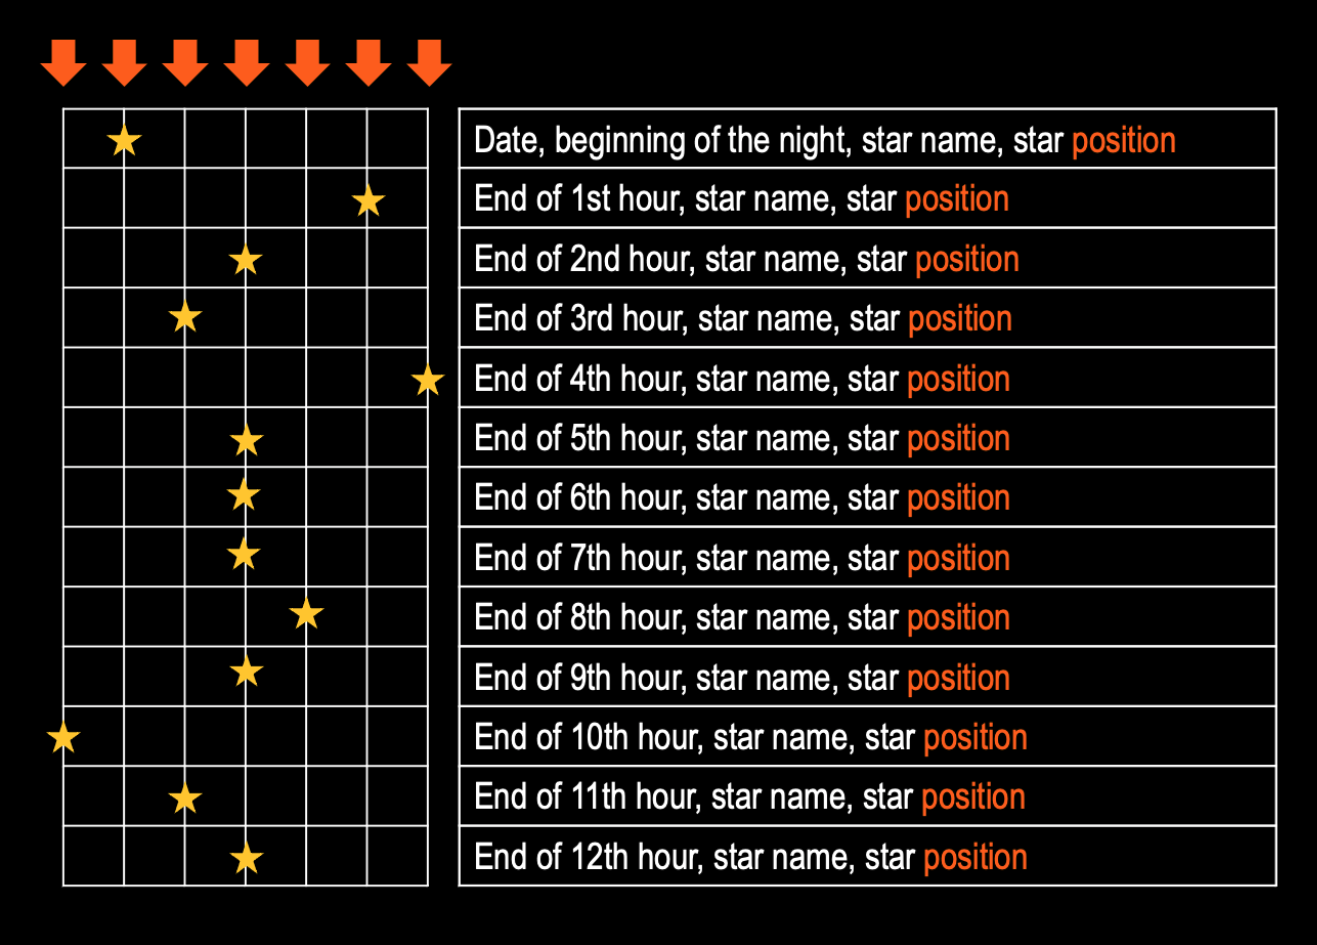

In [13]:
# Just a reminder of the sketch of the Ramesside Star Clock from Sarah's notes

from IPython import display
display.Image("../dev/notes/N&P/rsc_sketch_Sarah.png", width = 500)


TO DO: 

- finalize horizon-at-altitude decision
- now that we have dbc, make a 'closest to bin center' choice, just for funsies?
- optimize, standardize, otherwise make code non-heinous 

# Edits to choice algorithm 

Ok, so we basically want to add another worksheet to the excel sheet above via somehting like 

```python
# add full choice algorithm
df_choice = full_choice_select(df, params) #df = first worksheet with all options, params = TBD
df_choice.to_excel(writer, sheet_name='Full Choice',startrow= i * 15 + 5, startcol=0) 
worksheet4.write(i * 15 + 5,  0, "Table " + str(i + 1), format)  
```

The trick, of course, is creating the `full_choice_select(df, params)` function.   


In [ ]:
# A function to display dataframes side by side in Jupyter Notebook
# This function is from https://stackoverflow.com/questions/42208890/display-two-dataframes

from IPython.display import display_html
from itertools import chain,cycle
def display_side_by_side(*args,titles=cycle([''])):
    html_str=''
    for df,title in zip(args, chain(titles,cycle(['</br>'])) ):
        html_str+='<th style="text-align:center"><td style="vertical-align:top">'
        html_str+=f'<h2 style="text-align: center;">{title}</h2>'
        html_str+=df.to_html().replace('table','table style="display:inline"')
        html_str+='</td></th>'
    display_html(html_str,raw=True)


# main and helper functions for full-choice algorithm
from collections import Counter

def cosorted_by_magnitude(row_list, ind_list, mag_dict):
    '''
    Sorts the row_list and ind_list by the magnitude of the stars in row_list.
    Returns sorted lists.
    '''
    zipped = sorted(zip(row_list, ind_list), key=lambda x: mag_dict[x[0]])
    row_list, ind_list = zip(*zipped)
    return list(row_list), list(ind_list)

def cosorted_by_dict(list1, list2, sort_dict, ascending=True):
    """
    Co-sorts list1 and list2 based on the values of list1's elements in dict_.
    Returns the sorted lists.
    
    Args:
        list1: List of keys to sort by dict_ values.
        list2: List to be co-sorted with list1.
        dict_: Dictionary mapping elements of list1 to values.
        ascending: Sort order (default True for ascending).
    """
    zipped = sorted(zip(list1, list2), key=lambda x: sort_dict[x[0]], reverse=not ascending)
    if zipped:
        list1_sorted, list2_sorted = zip(*zipped)
        return list(list1_sorted), list(list2_sorted)
    else:
        return [], []


# def cosorted_by_dict_values(list1, list2, dict):
#     '''
#     Co-sort two lists based on the values of a dictionary.
#     Returns sorted lists.
#     '''
#     zipped = sorted(zip(list1, list2), key=lambda x: mag_dict[x[0]])
#     row_list, ind_list = zip(*zipped)
#     row_mag_list = [mag_dict[x] for x in row_list]
#     return list(row_list), list(ind_list), list(row_mag_list)


def sorted_magnitude_filter(row_list, ind_list, row_mag_list, threshold=0.5):
    ''' Function to filter out stars that are not within 0.5 mag of the first star.
        IMPORTANT: this function assumes that row_list and ind_list are already sorted by magnitude!
    '''    
    # set threshold for magnitude relative to the first star
    threshold += row_mag_list[0] 
    # filter out stars that are not within the threshold
    keep = [idx for idx, mag in enumerate(row_mag_list) if mag <= threshold]
    row_list = [row_list[k] for k in keep]
    ind_list = [ind_list[k] for k in keep]
    return (row_list, ind_list)

def full_choice_data(df, i, mag_dict, dbc_dict):
    '''
    Optimized implementation of the full-choice algorithm.
    '''
    df_all = pd.DataFrame(data=np.empty((13, 10), dtype=str))  # 13 rows, 7 bins + 3 columns for separation, choice type, and comments
    #df_all.columns = [-3, -2, -1, 0, 1, 2, 3, "", "Code", " d_dbc"]

    row_list = []
    ind_list = []
    for j in range(-3, 4):
        dlist = list(filter(None, df[j][i].split(' ')))
        row_list += dlist
        ind_list += [j] * len(dlist)
    # STEP 0: trivial cases
    if len(row_list) == 1:      # Only one star in the row
        df_all.at[i, ind_list[0] + 3] = row_list[0]
        df_all.at[i, 8] = "S"
        if abs(ind_list[0] + 3) == 3:   # overwrite if also B3
            df_all.at[i, 8] = "B3"    
    elif len(row_list) == 0:    # No stars in the row
        df_all.at[i, 8] = "D"
    else:                       # Sort by magnitude
        #(row_listM, ind_listM) = cosorted_by_magnitude(row_list, ind_list, mag_dict)
        (row_list, ind_list) = cosorted_by_dict(row_list, ind_list, mag_dict)
        #if row_listM != row_list or ind_listM != ind_list:
        #    print("Warning: row_listM and row_list are not equal after sorting by magnitude.")
        row_mag_list = [mag_dict[x] for x in row_list]  # Get magnitudes of sorted stars

        # STEP A: magnitude cut
        if row_mag_list[1] - row_mag_list[0] > 0.5: 
            df_all.at[i, ind_list[0] + 3] = row_list[0]
            df_all.at[i, 8] = "A"
            return df_all

        # Filter to only stars within 0.5 mag of the brightest
        row_list, ind_list = sorted_magnitude_filter(row_list, ind_list, row_mag_list)

        # Count occurrences by absolute bin index
        abs_counts = Counter(abs(x) for x in ind_list)

        # STEPS B0-B3: bin with exactly one star in order of priority (0, -1/+1, -2/+2,-3/+3)
        for bin_idx in range(4):
            if abs_counts[bin_idx] == 1:
                chosen_idx = [k for k, v in enumerate(ind_list) if abs(v) == bin_idx][0]
                df_all.at[i, ind_list[chosen_idx] + 3] = row_list[chosen_idx]
                df_all.at[i, 8] = f"B{bin_idx}"
                return df_all
            elif abs_counts[bin_idx] > 1:
                # If more than one star in this bin, go to STEP C
                break
        # STEP C: closest to bin center
        (row_list, ind_list) = cosorted_by_dict(row_list, ind_list, dbc_dict)
        df_all.at[i, ind_list[0] + 3] = row_list[0]  # Assign the first star in the sorted list
        df_all.at[i, 8] = "C"  # Closest to bin center
        df_all.at[i, 9] = str(np.round(dbc_dict[row_list[1]] - dbc_dict[row_list[0]], 2))
    return df_all


In [273]:
###  Let's run the full choice algorithm on some case to check what happens

alt_window = (0, 45) # degrees 
horizon = (175, 185) # Note: MUST have smaller number first; 
bsize = 1 # bin size (must be 1 if gsize = 0)
gsize = 0 # gap size (relative to binsize) 

dflist = []
df_testlist = []
choice_type_dict = {'A': 0, 'B0': 0, 'B1': 0, 'B2': 0, 'B3': 0, 'C': 0, 'D': 0, 'S': 0} # dictionary to count choice types
dbc_dict = {i: {} for i in range(24)}  # initialize dbc dict for each table

for d in range(0, 24): # for each day
    date = d * 15 # days from first day in decan data
    df, dbc_table_dict = synRSC(date, alt_window, horizon, bsize, gsize, sunSet, sunRise, starlist, starsAz, starsAlt, starVisList)    # go through each row in chosen df
    df_test = pd.DataFrame(data=np.empty((13, 10), dtype=str))  # 13 rows, 7 bins, 1 exception, 1 spare
    for i in range(0, 13): # for each row
        dfout = full_choice_data(df, i, mag_dict, dbc_table_dict[i])
        df_test +=dfout
        choice_type_dict[df_test.at[i, 8]] += 1
    dflist.append(df)
    df_testlist.append(df_test)


In [274]:
# How many of each choice type do we have?
print("Choice type counts:")
for key, value in choice_type_dict.items():
    print(f"{key}: {value}") 

# I haven't seen a B3 appear....
# OH B3 and S are the same thing, so that's why I haven't seen B3 appear!! 
# Right, I shouldn't need to have S (I think?) --> what's happening?
# OK, so here's what I'm thinking: ALL B3's are S's, but not all S's are B3's.
# Because at the point of choosing B3, there are no other places for the single star to be
# But at the point of choosing B2, e.g, there could be a single star to be chosen, but there could also be at least one star in B3

Choice type counts:
A: 109
B0: 32
B1: 47
B2: 9
B3: 8
C: 38
D: 31
S: 38


In [279]:
i = 10 # look at some table

print("DataFrame for Table " + str(i) + ":")
# Choice Table
df_choice = df_testlist[i]
df_choice.columns = [-3, -2, -1, 0, 1, 2, 3, "", "Code", " d_dbc"]
display_side_by_side(df_choice, titles=['Chosen stars']) #we left 3rd empty...
# All Star Table
display_side_by_side(dflist[i], titles=['All stars']) #we left 3rd empty...

DataFrame for Table 10:


,-3,-2,-1,0,1,2,3,,Code,d_dbc
0,,H071683,,,,,,,A,
1,,,,H073273,,,,,B0,
2,,,,,,H077952,,,C,0.3
3,,,,H083081,,,,,B0,
4,,,,,,H082396,,,B2,
5,,,,,,,H085927,,A,
6,,,,,H090185,,,,A,
7,,,,,H092855,,,,A,
8,,H101772,,,,,,,S,
9,,,,,,,H101772,,S,


,-3,-2,-1,0,1,2,3
0,H074946,H071681 H071683 H071908,H069996,,,H068245 H068282 H068702,H068002
1,H077952,H074376,H073334 H073807 H074395,H073273,H074946,,H071860 H071908
2,,,,,H079664,H076297 H077952,
3,H085258 H085267,H085727 H086929,,H083081,H082363,,
4,H086228,,,H084143 H085792,,H082396 H085258 H085267,H082514 H082545 H082729 H085727 H086929
5,,H090422,,H087261,,H086670 H087073 H088714,H085927
6,H090496,,,H089931,H090185,,H088635 H089642
7,,,H093864,H095347,H092855 H093506,H095241,H092041
8,,H101772,,,,,
9,,,,,,,H101772


### Adding actual C values 

To make C-cuts according to centeredness in each bin, we have to pass that information from `synRSC1star()` and `synRSC()`. 

Let me first remind myself how azimuth bin selection works in the former:

In [148]:
# use some values that are easy to mentally divide

alt_window = (0, 45) # degrees 
horizon = (173, 187) # Note: MUST have smaller number first; 
bsize = 1 # bin size (must be 1 if gsize = 0)
gsize = 0 # gap size (relative to binsize) 

In [150]:
(horizon_bins, skip) = horizonBins(horizon, bsize, gsize)
print(horizon_bins)

[173. 175. 177. 179. 181. 183. 185. 187.]


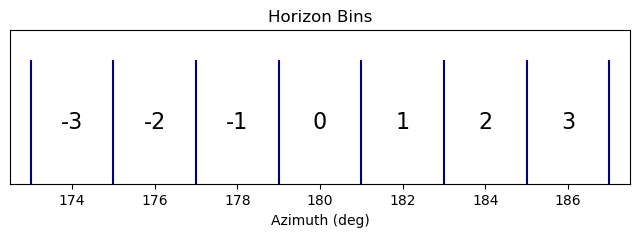

In [152]:
###  plot horizon bins
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 2))
for x in horizon_bins:
    plt.axvline(x, color='navy', linestyle='-', ymax=0.8)

# Add text between each pair of lines
binname = ['-3', '-2', '-1', '0', '1', '2', '3']
for i in range(len(horizon_bins) - 1):
    mid = (horizon_bins[i] + horizon_bins[i+1]) / 2
    plt.text(mid, 0.4, binname[i], ha='center', va='center', fontsize=16, color='black')

plt.xlim(min(horizon_bins)-bsize/2, max(horizon_bins)+bsize/2)  
plt.ylim(0, 1)
plt.yticks([])
plt.xlabel('Azimuth (deg)')
plt.title('Horizon Bins')
plt.show()

Ok, so we have bins defined *between* these lines, so what we want to know is the difference between each star's actual azimuth and the "mid" defined above. 

In [153]:
starind = 0
date_ind = 0 * 15 # example date index

for starind in range(0, 50):
    #stuff that normally gets pased by synRSC()
    starName = starlist[starind]  # just one star for now
    starAz = starsAz[starind]
    starAlt = starsAlt[starind]
    starVis = starVisList[starind]    
    #starlist[i], starAzlist[i], starAltlist[i], starVislist[i]

    # time bins
    sset = sunSet[date_ind] # RENAME!
    sris = sunRise[date_ind + 1] # RENAME!
    time_ind_bins = np.round(np.linspace(sset, sris, 14, endpoint=False))

    # bin star as appropriate 
    rsc_table = []
    # for i in range(0, 13):
    i = 0 # do this for one hour for now
    ind = int(time_ind_bins[i]) 
    inWindow = isStarInWindow(alt_window, starAlt[ind]) # leaving to make sure we're using a good example
    # TO DO: make inWindow also check that it's in the azimuth window, maybe? could save iterations 
    az_list = starAz[ind]   
    if starVis[date_ind] and inWindow and az_list > horizon[0] and az_list < horizon[1]:
        az_list = starAz[ind]
        row = np.histogram(az_list, horizon_bins)[0][::skip]
        #print(date_ind)
        print("in Window=" + str(inWindow)+", az_list = "+ str(az_list))
        print("starind = " + str(starind) + ", date_ind = " + str(date_ind) + ", row = " + str(row))
    # else:
    #     row = np.zeros(7, dtype=int)  
    # rsc_table.append(row)
    # print(row)

in Window=True, az_list = 177.73
starind = 46, date_ind = 0, row = [0 0 1 0 0 0 0]


In [163]:
starind = 46
date_ind = 0 * 15 

starName = starlist[starind]  # just one star for now
starAz = starsAz[starind]
starAlt = starsAlt[starind]
starVis = starVisList[starind]    

# time bins
sset = sunSet[date_ind] # RENAME!
sris = sunRise[date_ind + 1] # RENAME!
time_ind_bins = np.round(np.linspace(sset, sris, 14, endpoint=False))

# bin star as appropriate 
rsc_table = []
# for i in range(0, 13):
i = 0 # do this for one hour for now
ind = int(time_ind_bins[i]) 
inWindow = isStarInWindow(alt_window, starAlt[ind]) # leaving to make sure we're using a good example
# TO DO: make inWindow also check that it's in the azimuth window, maybe? could save iterations 

# The actual binning:
az_list = starAz[ind]   
row = np.histogram(az_list, horizon_bins)[0][::skip]

Ok, so at this point I want to save dbin_center, which is the distance from the bin center. 

In [ ]:
horizon_bin_centers = (horizon_bins[0:-1] + horizon_bins[1:]) / 2
dbin_center = np.round(min(np.abs(horizon_bin_centers - az_list)), 4)

In [175]:
print(horizon_bins)
horizon_bin_centers = (horizon_bins[0:-1] + horizon_bins[1:]) / 2
print(horizon_bin_centers)

dbin_center = np.round(min(np.abs(horizon_bin_centers - az_list)), 4)
print(dbin_center)
print(az_list)

[173. 175. 177. 179. 181. 183. 185. 187.]
[174. 176. 178. 180. 182. 184. 186.]
0.27
177.73


Now the question is do I want to return this as part of `synRSC1star()` or just ad-hoc calculate it for the stars already being marked C?

I guess the pro of properly returning it for all candidate stars is it makes it easier to do a `bin_center_choice()`. 

In [206]:
def synRSC1star(date_ind, alt_window, horizon, bsize, gsize, sunSet, sunRise, starName, starAz, starAlt, starVis):
    '''
    Function which, when given a date, size of horizon, and single star's data*, 
    makes a synthetic Ramesside Star Clock.
    Also returns a dictionary of dbin_center for each star and time bin.
    '''
    # transform horizon limits according to the altitude window
    horizon = horizon_altitude_transform(horizon, alt_window)
    # define horizon bin limits (assuming equal binsize)
    (horizon_bins, skip) = horizonBins(horizon, bsize, gsize)
    horizon_bin_centers = (horizon_bins[0:-1] + horizon_bins[1:]) / 2 # centers of bins for calculating dbc
    # define time bin limits (assuming equal binsize)
    sset = sunSet[date_ind]
    sris = sunRise[date_ind + 1]
    time_ind_bins = np.round(np.linspace(sset, sris, 14, endpoint=False))
    rsc_table = []
    dbc_dict = {}  # distance from bin center dictionary, will look like {i: {starName: dbc}}
    for i in range(0, 13):
        ind = int(time_ind_bins[i])
        inWindow = isStarInWindow(alt_window, starAlt[ind])
        az_list = starAz[ind]
        if starVis[date_ind] and inWindow and az_list > horizon[0] and az_list < horizon[1]:
            row = np.histogram(az_list, horizon_bins)[0][::skip]
            dbc = np.round(min(np.abs(horizon_bin_centers - az_list)), 4)
            dbc_dict[i] = {starName: dbc}
        else:
            row = np.zeros(7, dtype=int)
        rsc_table.append(row)
    return np.array(rsc_table), dbc_dict

def synRSC(date_ind, alt_window, horizon, bsize, gsize, sunSet, sunRise, starlist, starAzlist, starAltlist, starVislist):
    '''
    Function to create synthetic Ramesside Star Clocks given data from several stars.
    Also returns a dictionary: {i: {starName: dbc, ...}, ...}
    '''
    df = pd.DataFrame(data=np.empty((13,7), dtype=str))
    dbc_dict = {i: {} for i in range(13)}  # initialize dbc_dict

    for i in range(len(starlist)):
        temp_table, dbc_temp = synRSC1star(
            date_ind, alt_window, horizon, bsize, gsize,
            sunSet, sunRise, starlist[i], starAzlist[i], starAltlist[i], starVislist[i]
        )
        inds = np.argwhere(temp_table == 1)
        for ind in inds:
            df.at[ind[0], ind[1]] += (starlist[i] + " ")
        # Merge dbc_temp into dbc_dict
        for k, v in dbc_temp.items():
            dbc_dict[k].update(v)
    df.columns = [-3, -2, -1, 0, 1, 2, 3]
    return df, dbc_dict

In [207]:
df, dbc_table = synRSC(date, alt_window, horizon, bsize, gsize, sunSet, sunRise, starlist, starsAz, starsAlt, starVisList)
print(dbc_table)  # print the dbc_table for debugging

{0: {'H014879': 0.2294, 'H015474': 0.0184, 'H016537': 0.8426, 'H017378': 0.0723, 'H018543': 0.8553}, 1: {'H019747': 0.1833, 'H020042': 0.0301, 'H020535': 0.5803, 'H021393': 0.7064, 'H021594': 0.2851}, 2: {'H019747': 0.5197, 'H020535': 0.8766, 'H021393': 0.1206, 'H023685': 0.2509, 'H024305': 0.7869, 'H025606': 0.2703, 'H025985': 0.0217}, 3: {'H025859': 0.5619, 'H026634': 0.5271, 'H027072': 0.1904, 'H027628': 0.4581, 'H027654': 0.1357, 'H028328': 0.1476, 'H030122': 0.8426, 'H030324': 0.4943}, 4: {'H028328': 0.8283, 'H030122': 0.3224, 'H030277': 0.5873, 'H030438': 0.2314, 'H031685': 0.3337, 'H032759': 0.7559, 'H033152': 0.374, 'H033579': 0.2553, 'H033856': 0.1647, 'H033977': 0.8749, 'H034444': 0.4304}, 5: {'H030438': 0.0319, 'H031685': 0.4494, 'H032768': 0.635, 'H035264': 0.884, 'H035904': 0.7273, 'H036377': 0.1727, 'H037229': 0.356, 'H037677': 0.0589, 'H037819': 0.1084, 'H038170': 0.0581}, 6: {'H038414': 0.4567, 'H038827': 0.4839, 'H039429': 0.3879, 'H039953': 0.1969, 'H042515': 0.2827, 

In [ ]:
# test the above
known_stars_dict = {}
dbc_dict = {i: {} for i in range(24)}  # initialize dbc dict for each table

for i in range(0, 3): # should be 24 but debugging 
    date = i * 15 # days from first day in decan data
    df, dbc_table = synRSC(date, alt_window, horizon, bsize, gsize, sunSet, sunRise, starlist, starsAz, starsAlt, starVisList)
    print(dbc_table)  # print the dbc_table for debugging
    dbc_dict[i] = dbc_table # store dbc_table for each table date
    #df_test.to_excel('output' + str(date) + '.xlsx', index=False)
    df.to_excel(writer, sheet_name='RSCs',startrow= i * 15 + 5, startcol=0)   
    #worksheet.write(i * 15 + 5,  0, "Table " + str(i + 1), format)
    #another_df.to_excel(writer,sheet_name='RSCs',startrow=20, startcol=0) 
    #add mag data
    df_mag = mag_data(df, mag_dict)
    #df_mag.to_excel(writer, sheet_name='Mag Select',startrow= i * 15 + 5, startcol=0) 
    #worksheet2.write(i * 15 + 5,  0, "Table " + str(i + 1), format)
    # add name or mag data
    (df_name, known_stars_dict) = name_or_mag_data(df, mag_dict, known_stars_dict)
    #df_name.to_excel(writer, sheet_name='Name Select',startrow= i * 15 + 5, startcol=0) 
    #worksheet3.write(i * 15 + 5,  0, "Table " + str(i + 1), format)

{0: {}, 1: {}, 2: {}, 3: {}, 4: {}, 5: {}, 6: {}, 7: {}, 8: {}, 9: {}, 10: {}, 11: {}, 12: {}}
{0: {}, 1: {}, 2: {}, 3: {}, 4: {}, 5: {}, 6: {}, 7: {}, 8: {}, 9: {}, 10: {}, 11: {}, 12: {}}


In [205]:
df, dbc_table = synRSC(date, alt_window, horizon, bsize, gsize, sunSet, sunRise, starlist, starsAz, starsAlt, starVisList)
print(dbc_table)  # print the dbc_table for debugging

Processing star: H014879
Star index: 53
dbc_temp = {0: {'H014879': 0.2294}}
{0: {'H014879': 0.2294}, 1: {}, 2: {}, 3: {}, 4: {}, 5: {}, 6: {}, 7: {}, 8: {}, 9: {}, 10: {}, 11: {}, 12: {}}
Processing star: H015474
Star index: 54
dbc_temp = {0: {'H015474': 0.0184}}
{0: {'H014879': 0.2294, 'H015474': 0.0184}, 1: {}, 2: {}, 3: {}, 4: {}, 5: {}, 6: {}, 7: {}, 8: {}, 9: {}, 10: {}, 11: {}, 12: {}}
{0: {'H014879': 0.2294, 'H015474': 0.0184}, 1: {}, 2: {}, 3: {}, 4: {}, 5: {}, 6: {}, 7: {}, 8: {}, 9: {}, 10: {}, 11: {}, 12: {}}
{0: {'H014879': 0.2294, 'H015474': 0.0184}, 1: {}, 2: {}, 3: {}, 4: {}, 5: {}, 6: {}, 7: {}, 8: {}, 9: {}, 10: {}, 11: {}, 12: {}}
{0: {'H014879': 0.2294, 'H015474': 0.0184}, 1: {}, 2: {}, 3: {}, 4: {}, 5: {}, 6: {}, 7: {}, 8: {}, 9: {}, 10: {}, 11: {}, 12: {}}
Processing star: H016537
Star index: 58
dbc_temp = {0: {'H016537': 0.8426}}
{0: {'H014879': 0.2294, 'H015474': 0.0184, 'H016537': 0.8426}, 1: {}, 2: {}, 3: {}, 4: {}, 5: {}, 6: {}, 7: {}, 8: {}, 9: {}, 10: {}, 11

In [204]:
def synRSC(date_ind, alt_window, horizon, bsize, gsize, sunSet, sunRise, starlist, starAzlist, starAltlist, starVislist):
    '''
    Function to create synthetic Ramesside Star Clocks given data from several stars.
    Also returns a dictionary: {i: {starName: dbc, ...}, ...}
    '''
    df = pd.DataFrame(data=np.empty((13,7), dtype=str))
    dbc_dict = {i: {} for i in range(13)}  # initialize dbc_dict

    #for i in range(len(starlist)):
    for i in range(53, 80): # debugging    
        temp_table, dbc_temp = synRSC1star(
            date_ind, alt_window, horizon, bsize, gsize,
            sunSet, sunRise, starlist[i], starAzlist[i], starAltlist[i], starVislist[i]
        )
        if dbc_temp:  # if dbc_temp is not empty
            print("Processing star: " + starlist[i])
            print("Star index: " + str(i))
            #print("temp_table = " + str(temp_table))    
            print("dbc_temp = " + str(dbc_temp))
        inds = np.argwhere(temp_table == 1)
        for ind in inds:
            df.at[ind[0], ind[1]] += (starlist[i] + " ")
        # Merge dbc_temp into dbc_dict
        for k, v in dbc_temp.items():
            dbc_dict[k].update(v)
        print(dbc_dict)    
    df.columns = [-3, -2, -1, 0, 1, 2, 3]
    return df, dbc_dict

In [186]:
dbc_dict[23][1]

{}

In [187]:
df

,-3,-2,-1,0,1,2,3
0,H008645,H008102,,,H006537,,H005364
1,,,,,H009347,,
2,H014879,,,,H013701,,
3,H018543,,,,H017378,H014879 H015474 H016537,
4,H021393,H019747 H020535,H020042 H021594,,,,
5,H025606 H025985,,,H023685 H024305,,H019747 H021393,H020535
6,H030324,,H027628,H026634,H025859 H027654,H027072,H028103
7,H030438 H031685 H033579 H033856 H033977,H032759,H033152,,H028328 H030277,H030122,H031592
8,H036377,H037677 H038170,H032768 H037229,H030438 H035264,H035904,H031685,
9,H042515 H042828,H038827 H039953,,H039429,H038414,,H036377 H037819


In [180]:
i

23

In [ ]:
def synRSC1star(date_ind, alt_window, horizon, bsize, gsize, sunSet, sunRise, starName, starAz, starAlt, starVis):
    '''
    Function which, when given a date, size of horizon, and single star's data*, 
    makes a synthetic Ramesside Star Clock.
    '''
    # transform horizon limits according to the altitude window
    horizon = horizon_altitude_transform(horizon, alt_window)
    # define horizon bin limits (assuming equal binsize)
    (horizon_bins, skip) = horizonBins(horizon, bsize, gsize)
    horizon_bin_centers = (horizon_bins[0:-1] + horizon_bins[1:]) / 2 # centers of bins for calculating dbin_center
    dbc_list = [] # list to save dbin_center for each star
    # define time bin limits (assuming equal binsize)
    sset = sunSet[date_ind]
    sris = sunRise[date_ind + 1]
    #time_bins = np.linspace(jd[sset], jd[srise], 14)
    time_ind_bins = np.round(np.linspace(sset, sris, 14, endpoint=False))
    # bin star as appropriate 
    rsc_table = []
    for i in range(0, 13):
        ind = int(time_ind_bins[i]) # is this the index I want to be passing? 
        inWindow = isStarInWindow(alt_window, starAlt[ind])
        az_list = starAz[ind]   
        if starVis[date_ind] and inWindow and az_list > horizon[0] and az_list < horizon[1]:
        #if starVis[date_ind] and inWindow:
            az_list = starAz[ind]
            row = np.histogram(az_list, horizon_bins)[0][::skip]
            dbc = np.round(min(np.abs(horizon_bin_centers - az_list)), 4) #dbin_center
            dbc_row[starName] = dbc # save dbin_center for this star
            #print(date_ind)
            #print("in Window=" + str(inWindow)+", az_list = "+ str(az_list))
        else:
            row = np.zeros(7, dtype=int)  
        rsc_table.append(row)
        dbin_center[i] += dbc_row
    return(np.array(rsc_table))

def synRSC(date_ind, alt_window, horizon, bsize, gsize, sunSet, sunRise, starlist, starAzlist, starAltlist, starVislist):
    '''
    Function to create synthetic Ramesside Star Clocks given data from several stars.
    '''
    # how many stars
    df = pd.DataFrame(data=np.empty((13,7), dtype=str))
    # iterate over stars
    for i in range(len(starlist)):
        temp_table = synRSC1star(date_ind, alt_window, horizon, bsize, gsize, sunSet, sunRise, starlist[i], starAzlist[i], starAltlist[i], starVislist[i])
        inds = np.argwhere(temp_table == 1)
        for ind in inds:
            df.at[ind[0], ind[1]] += (starlist[i] + " ")   
    df.columns = [-3, -2, -1, 0, 1, 2, 3]
    return df

### Do all the choices appear and how often?

In [224]:
df_test = pd.DataFrame(data=np.empty((13, 9), dtype=str))  # 13 rows, 7 bins, 1 exception, 1 spare

for i in range(0, 13): # for each row
    dfout = full_choice_data(df, mag_dict, i)
    df_test +=dfout
#print(df_test)    

#display_side_by_side(df,df_test, titles=['Full','Choice']) #we left 3rd empty...


TypeError: full_choice_data() missing 1 required positional argument: 'dbc_dict'

In [ ]:
###  Question: How many times does each chouce type occur?

alt_window = (0, 45) # degrees 
horizon = (175, 185) # Note: MUST have smaller number first; 
bsize = 1 # bin size (must be 1 if gsize = 0)
gsize = 0 # gap size (relative to binsize) 

dflist = []
df_testlist = []
choice_type_dict = {'A': 0, 'B0': 0, 'B1': 0, 'B2': 0, 'B3': 0, 'C': 0, 'D': 0, 'S': 0} # dictionary to count choice types


for d in range(0, 24): # for each day
    date = d * 15 # days from first day in decan data
    df = synRSC(date, alt_window, horizon, bsize, gsize, sunSet, sunRise, starlist, starsAz, starsAlt, starVisList)
    # go through each row in chosen df
    df_test = pd.DataFrame(data=np.empty((13, 9), dtype=str))  # 13 rows, 7 bins, 1 exception, 1 spare
    for i in range(0, 13): # for each row
        dfout = full_choice_data(df, i, mag_dict, )
        df_test +=dfout
        choice_type_dict[df_test.at[i, 8]] += 1
    dflist.append(df)
    df_testlist.append(df_test)

print("Choice type counts:")
for key, value in choice_type_dict.items():
    print(f"{key}: {value}") 

# I haven't seen a B3 appear....
# OH B3 and S are the same thing, so that's why I haven't seen B3 appear!! 
# Right, I shouldn't need to have S (I think?) --> what's happening?
# OK, so here's what I'm thinking: ALL B3's are S's, but not all S's are B3's.
# Because at the point of choosing B3, there are no other places for the single star to be
# But at the point of choosing B2, e.g, there could be a single star to be chosen, but there could also be at least one star in B3


Choice type counts:
A: 109
B0: 32
B1: 47
B2: 9
B3: 8
C: 38
D: 31
S: 38


In [67]:
date = 0 * 15 # error appears in first table above
df = synRSC(date, alt_window, horizon, bsize, gsize, sunSet, sunRise, starlist, starsAz, starsAlt, starVisList)
display_side_by_side(df, titles=['Full Table','Choice']) #we left 3rd empty...


,-3,-2,-1,0,1,2,3
0,,H013701,,,,,
1,,,H017378,,H016537,H014879 H015474,
2,H020042,,,,,,
3,,,H023685 H024305,,,H019747 H021393,H020535
4,,H026634,H025859 H027654,H027072,H028103,H027288,
5,,,,H028328 H030277,H030122,H031592,
6,H037229,H032768 H035264,H035904,H030438,,H031685,H034444
7,,,H039429,,H038414,,H036377 H037819
8,H044511 H044816,H041037 H042913,H042536,H043023,H042570,,H038827
9,H048774,,H045101 H046701,H045080 H045556 H045941,H043783,,


In [59]:
# if I run the choice algorithm on the table, what do I get in Row 1?
dfout = full_choice_data(df, mag_dict, 1)
print(dfout)

   0 1 2 3 4        5 6 7  8
0                           
1             H009347      S
2                           
3                           
4                           
5                           
6                           
7                           
8                           
9                           
10                          
11                          
12                          


In [53]:
# Row #1 has only one star in +2; let's move it to +3 
print(df[2][1])
df[3][1] = df[2][1] # move this star to B3 to test the above 
df[2][1] = '' # and delete B2 position  

dfout = full_choice_data(df, mag_dict, 1)
print(dfout)


   0 1 2 3 4 5 6 7  8
0                    
1                   D
2                    
3                    
4                    
5                    
6                    
7                    
8                    
9                    
10                   
11                   
12                   


In [ ]:
df[3][1] = df[2][1] # move this star to B3 to test the above 
df[2][1] = '' # and delete B2 position  

In [110]:
d = 1
date = d * 15 # days from first day in decan data
df = synRSC(date, alt_window, horizon, bsize, gsize, sunSet, sunRise, starlist, starsAz, starsAlt, starVisList)
df_test = pd.DataFrame(data=np.empty((13, 9), dtype=str))  # 13 rows, 7 bins, 1 exception, 1 spare

for i in range(0, 13): # for each row
    dfout = full_choice_data(df, mag_dict, i)
    df_test +=dfout
print(df_test)

          0        1        2        3        4        5        6 7   8
0                     H018543                                         A
1                              H020042                               B0
2                                                                     C
3   H030438                                                           A
4                              H030438                                A
5                                                         H030438     A
6                                                                     C
7                                       H045556                      B1
8                                       H052419                      B1
9                              H060718                               B0
10           H071683                                                  A
11                                               H071683              A
12                    H083081                                   

### Older versions of choice algo

In [ ]:
from collections import Counter

def cosorted_by_magnitude(row_list, ind_list, mag_dict):
    '''
    Sorts the row_list and ind_list by the magnitude of the stars in row_list.
    Returns sorted lists.
    '''
    zipped = sorted(zip(row_list, ind_list), key=lambda x: mag_dict[x[0]])
    row_list, ind_list = zip(*zipped)
    row_mag_list = [mag_dict[x] for x in row_list]
    return list(row_list), list(ind_list), list(row_mag_list)

def sorted_magnitude_filter(row_list, ind_list, row_mag_list, threshold=0.5):
    ''' Function to filter out stars that are not within 0.5 mag of the first star.
        IMPORTANT: this function assumes that row_list and ind_list are already sorted by magnitude!
    '''    
    # set threshold for magnitude relative to the first star
    threshold += row_mag_list[0] 
    # filter out stars that are not within the threshold
    keep = [idx for idx, mag in enumerate(row_mag_list) if mag <= threshold]
    row_list = [row_list[k] for k in keep]
    ind_list = [ind_list[k] for k in keep]
    return (row_list, ind_list)

def full_choice_data(df, mag_dict, i):
    '''
    Optimized implementation of the full-choice algorithm.
    '''
    df_all = pd.DataFrame(data=np.empty((13, 9), dtype=str))  # 13 rows, 7 bins, 1 exception, 1 spare
    #i = 2  # read in one row for testing

    row_list = []
    ind_list = []
    for j in range(-3, 4):
        dlist = list(filter(None, df[j][i].split(' ')))
        row_list += dlist
        ind_list += [j] * len(dlist)
    # STEP 0: trivial cases
    if len(row_list) == 1:      # Only one star in the row
        df_all.at[i, ind_list[0] + 3] = row_list[0]
        df_all.at[i, 8] = "S"   
    elif len(row_list) == 0:    # No stars in the row
        df_all.at[i, 8] = "D"
    else:                       # Sort by magnitude
        (row_list, ind_list, row_mag_list) = cosorted_by_magnitude(row_list, ind_list, mag_dict)

        # STEP A: magnitude cut
        if row_mag_list[1] - row_mag_list[0] > 0.5: 
            df_all.at[i, ind_list[0] + 3] = row_list[0]
            df_all.at[i, 8] = "A"
            return df_all

        # Filter to only stars within 0.5 mag of the brightest
        row_list, ind_list = sorted_magnitude_filter(row_list, ind_list, row_mag_list)

        # Count occurrences by absolute bin index
        abs_counts = Counter(abs(x) for x in ind_list)

        # STEPS B0-B3: bin with exactly one star in order of priority (0, -1/+1, -2/+2,-3/+3)
        for bin_idx in range(4):
            if abs_counts[bin_idx] == 1:
                chosen_idx = [k for k, v in enumerate(ind_list) if abs(v) == bin_idx][0]
                df_all.at[i, ind_list[chosen_idx] + 3] = row_list[chosen_idx]
                df_all.at[i, 8] = f"B{bin_idx}"
                return df_all
            elif abs_counts[bin_idx] > 1:
                # If more than one star in this bin, go to STEP C
                break
        # STEP C: closest to bin center
        df_all.at[i, 8] = "C"  # Closest to bin center (TODO: implement logic)
    return df_all


In [79]:
# def sorted_magnitude_filter(row_list, ind_list, row_mag_list, threshold=0.5):
#     ''' Function to filter out stars that are not within 0.5 mag of the first star.
#         IMPORTANT: this function assumes that row_list and ind_list are already sorted by magnitude!
#     '''    
#     # set threshold for magnitude relative to the first star
#     threshold += row_mag_list[0] 
#     # filter out stars that are not within the threshold
#     keep = [idx for idx, mag in enumerate(row_mag_list) if mag <= threshold]
#     row_list = [row_list[k] for k in keep]
#     ind_list = [ind_list[k] for k in keep]
#     return (row_list, ind_list)

# def full_choice_data(df, mag_dict):
#     '''
#     Implementing the full-choice algorithm.
#     '''
#     # data frame to save magnitude-selected data
#     df_all = pd.DataFrame(data=np.empty((13,9), dtype=str)) # wider to allow for exception column
#     # begin iterating 
#     #for i in range(0, 13): # for each row
#     i = 2 # start with just one row for testing purposes
#     row_list = [] # list of stars in row
#     ind_list = [] # index of candidate stars in row 
#     for j in range(-3, 4): # iterate through columns in row ( = horizon bins)
#         dlist = list(filter(None, df[j][i].split(' '))) # split into star names and filter out empty strings 
#         row_list += dlist
#         ind_list += [j] * len(dlist)
#     # at this point, have all the stars in the row
#     # STEP 0: check if len(row_list) > 1
#     #
#     if len(row_list)==1:
#         df_all.at[i, ind_list[0] + 3] = row_list[0]
#     elif len(row_list)==0:
#         df_all.at[i, 8] = "D" # exception; no stars available
#     # Now start making choices
#     #row_list.sort(key=lambda x: mag_dict[x]) # sort by increasing magnitude
#     row_list, ind_list = zip(*sorted(zip(row_list, ind_list), key=lambda x: mag_dict[x[0]])) # sort by increasing magnitude
#     row_list = list(row_list) # convert to list
#     ind_list = list(ind_list) # convert to list
#     row_mag_list = [mag_dict[x] for x in row_list] # list of magnitudes of stars in row
#     print(row_list, ind_list, row_mag_list) # for testing purposes
#     # STEP A: brighness cuts
#     if row_mag_list[0] - row_mag_list[1] > 0.5:
#         # if the first two stars are *not* within 0.5 mag of each other, choose the first one
#         df_all.at[i, ind_list[0] + 3] = row_list[0]  
#         df_all.at[i, 8] = "A" # exception; no stars available
#     # otherwise, filter out any stars that aren't within 0.5 mag of the first star
#     row_mag_list = [x for x in row_mag_list if x <= row_mag_list[0] + 0.5]
#     row_list = row_list[:len(row_mag_list)] # truncate to the same length
#     ind_list = ind_list[:len(row_mag_list)] # truncate to the same length
#     # STEP B: positon choices
#     # first, count number of stars with the same |index|
#     ind_count = [0,0,0,0]  # initialize a list to count occurrences of each index
#     for x in ind_list:
#         ind_count[abs(x)] += 1
#     # STEP B0: if one star is in the first bin, choose it
#     if ind_count[0] == 1:
#         df_all.at[i, 0 + 3] = row_list[ind_list.index(0)]
#         df_all.at[i, 8] = "B0" # only one star in the central bin
#     elif ind_count[0] > 1:
#         return # go to Step C
#     # STEP B1: if one star is in the +1/-1 bin, choose it
#     elif ind_count[1] == 1: 
#         if 1 in ind_list:
#             df_all.at[i, 1 + 3] = row_list[ind_list.index(1)] 
#         else:
#             df_all.at[i, -1 + 3] = row_list[ind_list.index(-1)]       
#         df_all.at[i, 8] = "B1" # only one star in the +1/-1 bins            
#     elif ind_count[1] > 1:
#         return # go to Step C
#     # STEP B2: if one star is in the +2/-2 bin, choose it
#     elif ind_count[2] == 1: 
#         return # go to Step C
#         if 2 in ind_list:
#             df_all.at[i, 2 + 3] = row_list[ind_list.index(2)] 
#         else:
#             df_all.at[i, -2 + 3] = row_list[ind_list.index(-2)]       
#         df_all.at[i, 8] = "B2" # only one star in the +2/-2 bins
#     elif ind_count[2] > 1:
#         return # go to Step C
#     # STEP B2: if one star is in the +2/-2 bin, choose it
#     elif ind_count[3] == 1: 
#         if 3 in ind_list:
#             df_all.at[i, 3 + 3] = row_list[ind_list.index(3)] 
#         else:
#             df_all.at[i, -3 + 3] = row_list[ind_list.index(-3)]       
#         df_all.at[i, 8] = "B3" # only one star in the +3/-3 bins      
#     elif ind_count[3] > 1:
#         return # go to Step C
#     # STEP C: if more than one choice above, choose the one closest to its bin's center
#     # NEED to pass some azimuth information here, TO DO             


In [ ]:
# some testing examples

row_list = ['H016537', 'H014879', 'H015474', 'H013701']
ind_list = [-2, -1, -1, 3]

(row_list, ind_list, row_mag_list) = cosorted_by_magnitude(row_list, ind_list, mag_dict)
print(row_list, ind_list, row_mag_list)

In [101]:
# for d in range(0, 5):
#     date = d * 15 # days from first day in decan data
#     df = synRSC(date, alt_window, horizon, bsize, gsize, sunSet, sunRise, starlist, starsAz, starsAlt, starVisList)
#     df_test = pd.DataFrame(data=np.empty((13, 9), dtype=str))  # 13 rows, 7 bins, 1 exception, 1 spare

#     for i in range(0, 13): # for each row
#         dfout = full_choice_data(df, mag_dict, i)
#         df_test +=dfout
#     print(df_test)

    

In [91]:
df[2][1]

'H009347 '

In [85]:
# dlist = list(filter(None, df[j][i].split(' ')))

# df[5][1]

In [ ]:
        # STEPS B0-B3: bin with exactly one star in order of priority (0, -1/+1, -2/+2,-3/+3)
        for bin_idx in range(4):
            if abs_counts[bin_idx] == 1:
                chosen_idx = [k for k, v in enumerate(ind_list) if abs(v) == bin_idx][0]
                df_all.at[i, ind_list[chosen_idx] + 3] = row_list[chosen_idx]
                df_all.at[i, 8] = f"B{bin_idx}"
                return df_all
            elif abs_counts[bin_idx] > 1:
                break # If more than one star in this bin, go to STEP C

In [ ]:
# from collections import Counter

# def full_choice_data(df, mag_dict, i):
#     '''
#     Full-choice algorithm as described in the steps.
#     '''
#     df_all = pd.DataFrame(data=np.empty((13, 9), dtype=str))  # 13 rows, 7 bins, 1 exception, 1 spare
#     #i = 2  # Example: process only row 2 for testing

#     row_list = []
#     ind_list = []
#     for j in range(-3, 4):
#         dlist = list(filter(None, df[j][i].split(' ')))
#         row_list += dlist
#         ind_list += [j] * len(dlist)

#     if len(row_list) == 1:
#         df_all.at[i, ind_list[0] + 3] = row_list[0]
#         df_all.at[i, 8] = "0"  # Single star found  
#         return df_all
#     elif len(row_list) == 0:
#         df_all.at[i, 8] = "D"
#         return df_all

#     # Sort by magnitude
#     zipped = sorted(zip(row_list, ind_list), key=lambda x: mag_dict[x[0]])
#     row_list, ind_list = zip(*zipped)
#     row_list = list(row_list)
#     ind_list = list(ind_list)
#     row_mag_list = [mag_dict[x] for x in row_list]

#     # STEP A: brightness cut
#     if len(row_mag_list) > 1 and row_mag_list[1] - row_mag_list[0] >= 0.5:
#         df_all.at[i, ind_list[0] + 3] = row_list[0]
#         df_all.at[i, 8] = "A"
#         return df_all

#     # Filter to only stars within 0.5 mag of the brightest
#     threshold = row_mag_list[0] + 0.5
#     keep = [idx for idx, mag in enumerate(row_mag_list) if mag <= threshold]
#     row_list = [row_list[k] for k in keep]
#     ind_list = [ind_list[k] for k in keep]
#     print(ind_list)  # for testing purposes
    
#     # STEP B0-B3: check bins in order 0, 1, 2, 3
#     for bin_idx in range(4):
#         candidates = [k for k, v in enumerate(ind_list) if abs(v) == bin_idx]
#         if len(candidates) == 1:
#             chosen_idx = candidates[0]
#             df_all.at[i, ind_list[chosen_idx] + 3] = row_list[chosen_idx]
#             df_all.at[i, 8] = f"B{bin_idx}"
#             return df_all
#         elif len(candidates) > 1:
#             df_all.at[i, 8] = f"C{bin_idx}"  # ambiguous, go to Step C if needed
#             return df_all
#         # else, continue to next bin

#     # If still ambiguous after all bins
#     df_all.at[i, 8] = "C"
#     return df_all

In [277]:
full_choice_data(df, mag_dict, 6)

,0,1,2,3,4,5,6,7,8
0,,,,,,,,,
1,,,,,,,,,
2,,,,,,,,,
3,,,,,,,,,
4,,,,,,,,,
5,,,,,,,,,
6,H030438,,,,,,,,A
7,,,,,,,,,
8,,,,,,,,,
9,,,,,,,,,


In [248]:
ind_list = [-3, -3, 1, 2, 3]  # your list of integers in [-3, 3]
ind_count = [0,0,0,0]  # initialize a list to count occurrences of each inde
for x in ind_list:
    ind_count[abs(x)] += 1

In [ ]:
row_list = ['H008645', 'H008102', 'H006537', 'H005364']
row_list2 = ['H008645', 'H006537', 'H008102', 'H005364']

mag_list = [mag_dict['H008645'], mag_dict['H008102'], mag_dict['H006537'], mag_dict['H005364']]

print(row_list)
print(mag_list)

['H008645', 'H008102', 'H006537', 'H005364']
[3.74, 3.49, 3.6, 3.46]


In [246]:
ind_count

[0, 1, 1, 3]

In [220]:
row_mag_list = [0.5, 0.7, 0.8, 0.99, 1.04, 1.1, 1.2, 1.3]
row_mag_list = [x for x in row_mag_list if x <= row_mag_list[0] + 0.5]
print(row_mag_list)

[0.5, 0.7, 0.8, 0.99]


In [231]:
lst = [-3, -3, 0, 1, 0, 2, 3]  # your list of integers in [-3, 3]
ind_count = [0,0,0,0]  # initialize a list to count occurrences of each inde
for x in lst:
    ind_count[abs(x)] += 1

In [232]:
ind_count

[2, 1, 1, 3]

In [226]:
lst = [-3, -3, 0, 1, 0, 2, 3]  # your list of integers in [-3, 3]
ind_count = {i: 0 for i in range(4)}
for x in lst:
    ind_count[abs(x)] += 1

In [230]:
print(ind_count.values())

dict_values([2, 1, 1, 3])


In [223]:
print(counts)

{0: 2, 1: 1, 2: 1, 3: 3}


In [ ]:
lst = [...]  # your list of integers in [-3, 3]
counts = {i: 0 for i in range(4)}
for x in lst:
    counts[abs(x)] += 1
print(counts)

In [ ]:
# Given a sorted ascending list (e.g., mag_list), cut off all values above a threshold
threshold = 3.6
filtered_list = [x for x in mag_list if x <= threshold]

In [200]:
l1 = [4,5,1,3,2]
l2 = ['h','e','l','l','o']
l3 = ['p','l','a','n','e']

temp = zip(l1, l2, l3)

In [201]:
temp

In [196]:
list2

['l', 'o', 'h', 'l', 'e']

In [191]:
test_dict = {}
print(test_dict)

test_dict['starname'] = 1 
print(test_dict)
print(len(test_dict))
l1, l2, l3 = zip(*sorted(zip(l1, l2, l3)))

{}
{'starname': 1}
1


TypeError: 'list' object is not callable

In [210]:
row_list = ['H008645', 'H008102', 'H006537', 'H005364']
row_list_expect = ['H005364', 'H008102', 'H006537', 'H008645']
clist = [4, 2, 3, 1] # column indices

row_list, clist = zip(*sorted(zip(row_list, clist), key=lambda x: mag_dict[x[0]]))

print(row_list)
print(clist)


('H005364', 'H008102', 'H006537', 'H008645')
(1, 2, 3, 4)


In [ ]:
row_list
clist


['H005364', 'H008102', 'H006537', 'H008645']

In [204]:
del sorted

In [ ]:
del sorted  # Remove the variable named 'sorted' if it exists

In [ ]:
row_list, clist = zip(*sorted(zip(row_list, clist), key=lambda x: mag_dict[x[0]]))
row_list = list(row_list)
clist = list(clist)


In [ ]:
(test1, test2) = zip(*sorted(zip(mag_list, row_list)))

In [189]:


mag_list, row_list = zip(*sorted(zip(mag_list, row_list)))
mag_list = list(mag_list)
row_list = list(row_list)

TypeError: 'list' object is not callable

In [188]:
row_list
test_dict = {}

test_dict[row_list] = 1 

TypeError: unhashable type: 'list'

In [ ]:
row_list.sort(key=lambda x: mag_dict[x], reverse=True) # descending order (brightest first)

In [107]:
[1] * 3

[1, 1, 1]

In [105]:
emptylist = []

In [106]:
emptylist[0]

IndexError: list index out of range

In [102]:
full_choice_data(df)

['H008645', 'H008102', 'H006537', 'H005364']


In [ ]:
def mag_data(df, mag_dict):
    '''
    Given a data frame made with synRSC and a name-to-magnitude value dictionary, 
    this function will select the brightest star in each row (aka horizon bin) to 
    create a magnitude-selected Ramesside Star Clock.  
    '''
    # data frame to save magnitude-selected data
    df_mag = pd.DataFrame(data=np.empty((13,7), dtype=str))
    # iterate through df of all possible stars and select for magnitude
    for i in range(0, 13):
        sname = ""
        min_mag = 10 # all human visible magnitudes should be higher than this 
        # iterate through columns in row ( = horizon bins)
        for j in range(-3, 4):
            j *= -1 # testing something 
            dlist = list(filter(None, df[j][i].split(' '))) # split into star names and filter out empty strings 
            for item in dlist:
                if mag_dict[item] < min_mag:
                    min_mag = mag_dict[item] # update brightest available star
                    cind = j + 3 # column index
                    sname = item # star name 
        if len(sname) > 1:                     
            df_mag.at[i, cind] = sname
    df_mag.columns = [-3, -2, -1, 0, 1, 2, 3]
    return(df_mag)


def name_or_mag_data(df, mag_dict, known_stars):
    '''
    Given a data frame made with synRSC, a name-to-magnitude value dictionary, and a known-star dictionary, 
    this function will select the known brightest star in each row (aka horizon bin) to 
    create a magnitude-selected Ramesside Star Clock;
    if no known stars, it defaults to brightest. 

    BEWARE: call this the alpha version of this function; it is the FARTHEST thing from elegant or optimized.   
    '''
    # data frame to save magnitude-selected data
    df_magname = pd.DataFrame(data=np.empty((13,7), dtype=str))
    # iterate through df of all possible stars and select for "known stars", then magnitude
    for i in range(0, 13): # for each row
        row_list = [] #list of stars in row
        for j in range(-3, 4): # iterate through columns in row ( = horizon bins)
            dlist = list(filter(None, df[j][i].split(' '))) # split into star names and filter out empty strings 
            row_list += dlist
        scand_list = [] # list of known candidate stars 
        for scand in row_list:
            if scand in known_stars:
                scand_list.append(scand)     
        # CASE 1: no previously known stars, choose by magnitude and add to known star list 
        if len(scand_list) == 0: 
            sname=''
            min_mag = 10 # all human visible magnitudes should be higher than this 
            for j in range(-3, 4):
                dlist = list(filter(None, df[j][i].split(' '))) # split into star names and filter out empty strings 
                for item in dlist:
                    if mag_dict[item] < min_mag:
                        min_mag = mag_dict[item] # update brightest available star
                        cind = j + 3 # column index
                        sname = item # star name 
            if len(sname) > 1: # if it's found *no* stars, leave blank                
                df_magname.at[i, cind] = sname  
                known_stars[sname] = "K" + str(len(known_stars)).zfill(2) # update known star dictionary           
        # CASE 2: one known star, choose that one
        elif len(scand_list) == 1:
            sname = scand_list[0]
            for j in range(-3, 4): # iterate through columns in row ( = horizon bins)
                dlist = list(filter(None, df[j][i].split(' '))) # split into star names and filter out empty strings 
                if sname in dlist:
                    cind = j + 3 # column index
                    df_magname.at[i, cind] = sname 
                    #known_stars[sname] = "K" + str(len(known_stars)).zfill(2) # update known star dictionary 
        # CASE 3: several known stars, choose the brightest one 
        else:
            # first find the brightest available star
            min_mag = 10 # all human visible magnitudes should be higher than this 
            for scand in scand_list:
                if mag_dict[scand] < min_mag:
                    min_mag = mag_dict[scand] # update brightest available star
                    sname = scand # star name 
                    #known_stars[sname] = "K" + str(len(known_stars)).zfill(2) # update known star dictionary 
            for j in range(-3, 4): # now find position of star
                dlist = list(filter(None, df[j][i].split(' '))) # split into star names and filter out empty strings 
                if sname in dlist:
                    cind = j + 3 # column index
                    df_magname.at[i, cind] = sname 
    # return                 
    df_magname.columns = [-3, -2, -1, 0, 1, 2, 3]
    return(df_magname, known_stars)    


# Scratch

### Checking bins and gaps

In [ ]:
def horizonBins(horizon, bsize, gsize):
    # if gap size is zero, return as usual
    if gsize == 0:
        return((np.linspace(horizon[0], horizon[1], 8), 1))
    # otherwise, divide into smallest common denominator
    num = 7 * bsize + 6 * gsize + 1
    horizon_bins = np.linspace(horizon[0], horizon[1], num)
    #print(len(horizon_bins))
    # select indices to merge by bin/gap size
    ## first gaps
    ind_gap = np.zeros(14)
    ind_gap[1::2] = np.arange(0,7)
    ind_gap[::2] = np.arange(0,7)
    #print(ind_gap)
    ## then bins
    ind_bin = np.zeros(14)
    ind_bin[0:13] = ind_gap[1:]
    ind_bin[-1] = 7 
    #print(ind_bin)
    # add together with bin/gap sizes
    inds = ind_bin * bsize + ind_gap * gsize
    inds = inds.astype(int)
    #print(inds)
    # return only those bin and gap indices
    return((horizon_bins[inds], 2))


def synRSC1star(date_ind, alt_window, horizon, bsize, gsize, sunSet, sunRise, starName, starAz, starAlt, starVis):
    '''Function which, when given a date, size of horizon, and single star's data*, 
    makes a synthetic Ramesside Star Clock.'''
    # define horizon bin limits (assuming equal binsize)
    (horizon_bins, skip) = horizonBins(horizon, bsize, gsize)
    # define time bin limits (assuming equal binsize)
    sset = sunSet[date_ind]
    sris = sunRise[date_ind + 1]
    #time_bins = np.linspace(jd[sset], jd[srise], 14)
    time_ind_bins = np.round(np.linspace(sset, sris, 14, endpoint=False))
    print(sset)
    print(sris)
    print(time_ind_bins)
    #print(time_ind_bins)
    # bin star as appropriate 
    rsc_table = []
    for i in range(0, 13):
        ind = int(time_ind_bins[i]) # is this the index I want to be passing? 
        inWindow = isStarInWindow(alt_window, starAlt[ind])
        if starVis[date_ind] and inWindow:
            az_list = starAz[ind]
            row = np.histogram(az_list, horizon_bins)[0][::skip]
            print(np.histogram(az_list, horizon_bins)[0])
            print(row)
            #print(date_ind)
            #print("in Window=" + str(inWindow)+", az_list = "+ str(az_list))
        else:
            row = np.zeros(7, dtype=int)  
        rsc_table.append(row)
    return(np.array(rsc_table))    

In [36]:
alt_window = (0, 45) # degrees 
horizon = (170, 190) # Note: MUST have smaller number first; 
bsize = 1 # bin size (must be 1 if gsize = 0)
gsize = 0 # gap size (relative to binsize) 

dhour = 0.04166666674427688 #in Julian dates

(horizon_bins, skip) = horizonBins(horizon, bsize, gsize)

print(horizon_bins)

len(horizon_bins)

[170.         172.85714286 175.71428571 178.57142857 181.42857143
 184.28571429 187.14285714 190.        ]


8

In [37]:
(190 - 170) / (7 * bsize + 6 * gsize)

2.857142857142857

In [346]:
208 - 170

38

In [27]:
def horizonBins(horizon, bsize, gsize):
    # if gap size is zero, return as usual
    if gsize == 0:
        return((np.linspace(horizon[0], horizon[1], 8), 1))
    # otherwise, divide into smallest common denominator
    num = 7 * bsize + 7 * gsize #+ 1
    horizon_bins = np.linspace(horizon[0], horizon[1], num)
    #print(len(horizon_bins))
    # select indices to merge by bin/gap size
    ## first gaps
    ind_gap = np.zeros(14)
    ind_gap[1::2] = np.arange(0,7)
    ind_gap[::2] = np.arange(0,7)
    #print(ind_gap)
    ## then bins
    ind_bin = np.zeros(14)
    ind_bin[0:13] = ind_gap[1:]
    ind_bin[-1] = 7 
    #print(ind_bin)
    # add together with bin/gap sizes
    inds = ind_bin * bsize + ind_gap * gsize
    inds = inds.astype(int)
    #print(inds)
    # return only those bin and gap indices
    return((horizon_bins[inds], 2))

alt_window = (0, 45) # degrees 
horizon = (170, 190) # Note: MUST have smaller number first; 
bsize = 1 # bin size (must be 1 if gsize = 0)
gsize = 2 # gap size (relative to binsize) 
dhour = 0.04166666674427688 #in Julian dates
(horizon_bins, skip) = horizonBins(horizon, bsize, gsize)
print(horizon_bins)

[170. 171. 173. 174. 176. 177. 179. 180. 182. 183. 185. 186. 188. 189.]


In [301]:
n1 = horizon_bins[2] - horizon_bins[1]
n2 = horizon_bins[3] - horizon_bins[2]

print(n1)
print(n2)
print(n1/n2)
print(np.round(n1/n2,6)==np.round(gsize/bsize,6))

1.0144927536231876
9.130434782608717
0.11111111111111077
True


In [300]:
np.round(n1/n2,6)

0.111111

In [295]:
1/9

0.1111111111111111

In [20]:
date = 0 # days from first day in decan data

si = starlist.index('H013701') # a star I know will appear with bsize = 1 gsize = 0

synRSC1star(date, alt_window, horizon, bsize, gsize, sunSet, sunRise, starlist[si], starsAz[si], starsAlt[si], starVisList[si])

274
450
[274. 289. 303. 318. 333. 347. 362. 377. 391. 406. 421. 435. 450.]
[0 0 0 0 1 0 0 0 0 0 0 0 0]
[0 0 1 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0]


array([[0, 0, 1, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0]])

In [259]:
time_inds = [274, 289, 303, 318, 333, 347, 362, 377, 391, 406, 421, 435, 450]

for i in range(1, len(time_inds)):
    print(time_inds[i] - time_inds[i-1])
    print((jd[time_inds[i]] - jd[time_inds[i-1]])/dhour)

#(jd[318] - jd[289]) / dhour

15
1.0
14
0.9333333374311527
15
0.9999999944120646
15
1.0000000055879354
14
0.9333333318432172
15
0.9999999552965165
15
1.0
14
0.9333333318432172
15
1.0
15
1.0
14
0.9333333318432172
15
1.0


In [187]:
horizon_bins.shape

(8,)

### Other

Ha, it works! Some notes on things to do:

- general filestructure cleanup
    - the dictionary importing is hard coded right now--have it depends on direct, folder, filename, etc 
    - speaking of which, let's start naming files and folders similarly, so that IC filename --> decanOpy output folder --> SynRSC folder 
    - Clean up extraneous files and backup on git!
- maybe separate IC generation from decanOpy run?
    - this would involve figuring out how to point to a different star data csv for the real sky, which I have to do anyway
- RSC generator should be wrapped up in at least one more layer of functions
    - functions can also be stored in separate file 
    - in fact, decanO.py and co should probably go in their own folder and be imported properly (ayayay)
    - go through and comment the functions
    - generate readthedocs!
- RSC generator should have more choices
    - magnitude
    - "known star" THEN magnitude 
    - closest to center of bin 


    - Fake stars
        - maximum magnitude 4 
        - make sure not too many bright stars -- maybe not a uniform randomness?


        Largest Hipaprchos number for real data is 116727:
         -  name data as letter + 6 numbers, always a string 7-elements long


In [107]:
# inv_mag_dict = dict((v, k) for k, v in mag_dict.items())  ### invert dictionary

# # Python code to demonstrate 
# # finding duplicate values from a dictionary

# # initialising dictionary
# ini_dict = mag_dict


# # printing initial_dictionary
# print("initial_dictionary", str(ini_dict))

# # finding duplicate values
# # from dictionary
# # using a naive approach
# rev_dict = {}

# for key, value in ini_dict.items():
# 	rev_dict.setdefault(value, set()).add(key)
	
# result = [key for key, values in rev_dict.items()
# 							if len(values) > 1]

# # printing result
# print("duplicate values", str(result))


In [110]:
test_dict = {}

test_dict["name1"] = "name2"

print(test_dict)

{'name1': 'name2'}


In [27]:
testd_df_save = df

In [ ]:
def mag_data(df, mag_dict):
    '''
    Given a data frame made with synRSC and a name-to-magnitude value dictionary, 
    this function will select the brightest star in each row (aka horizon bin) to 
    create a magnitude-selected Ramesside Star Clock.  
    '''
    # data frame to save magnitude-selected data
    df_mag = pd.DataFrame(data=np.empty((13,7), dtype=str))
    # iterate through df of all possible stars and select for magnitude
    for i in range(0, 13):
        sname = ""
        min_mag = 10 # all human visible magnitudes should be higher than this 
        # iterate through columns in row ( = horizon bins)
        for j in range(-3, 4):
            dlist = list(filter(None, df[j][i].split(' '))) # split into star names and filter out empty strings 
            for item in dlist:
                if mag_dict[item] < min_mag:
                    min_mag = mag_dict[item] # update brightest available star
                    cind = j + 3 # column index
                    sname = item # star name 
        if len(sname) > 1:                     
            df_mag.at[i, cind] = sname
    df_mag.columns = [-3, -2, -1, 0, 1, 2, 3]
    return(df_mag)

In [44]:
def mag_or_name_data(df, mag_dict, known_stars):
    '''
    Given a data frame made with synRSC and a name-to-magnitude value dictionary, 
    this function will select the brightest star in each row (aka horizon bin) to 
    create a magnitude-selected Ramesside Star Clock.  
    '''
    # data frame to save magnitude-selected data
    df_magname = pd.DataFrame(data=np.empty((13,7), dtype=str))
    # iterate through df of all possible stars and select for magnitude
    for i in range(0, 13):
        sname = ""
        min_mag = 10 # all human visible magnitudes should be higher than this 
        # iterate through columns in row ( = horizon bins)
        for j in range(-3, 4):
            dlist = list(filter(None, df[j][i].split(' '))) # split into star names and filter out empty strings 
            for item in dlist:
                if mag_dict[item] < min_mag:
                    min_mag = mag_dict[item] # update brightest available star
                    cind = j + 3 # column index
                    sname = item # star name             
        # ok somewhere around here, I want to start making a dictionary of "known stars for comparison"
        scandlist = []; # empty list of star candidates
        for scand in dlist:
            if scand in known_stars:
                scandlist.append(scand)
            
        if len(sname) > 1: # if it's found *no* stars, leave blank
            # if no known stars                    
            df_magname.at[i, cind] = sname #choose the magnitude one
            # else
            # choose the known star
    df_magname.columns = [-3, -2, -1, 0, 1, 2, 3]
    return(df_magname)

In [105]:

def name_or_mag_data(df, mag_dict, known_stars):
    '''
    Given a data frame made with synRSC, a name-to-magnitude value dictionary, and a known-star dictionary, 
    this function will select the known brightest star in each row (aka horizon bin) to 
    create a magnitude-selected Ramesside Star Clock;
    if no known stars, it defaults to brightest. 

    BEWARE: call this the alpha version of this function; it is the FARTHEST thing from elegant or optimized.   
    '''
    # data frame to save magnitude-selected data
    df_magname = pd.DataFrame(data=np.empty((13,7), dtype=str))
    # iterate through df of all possible stars and select for "known stars", then magnitude
    for i in range(0, 13): # for each row
        row_list = [] #list of stars in row
        for j in range(-3, 4): # iterate through columns in row ( = horizon bins)
            dlist = list(filter(None, df[j][i].split(' '))) # split into star names and filter out empty strings 
            row_list += dlist
        scand_list = [] # list of known candidate stars 
        for scand in row_list:
            if scand in known_stars:
                scand_list.append(scand)
        # CASE 1: no previously known stars, choose by magnitude
        if len(scand_list) == 0: 
            min_mag = 10 # all human visible magnitudes should be higher than this 
            for j in range(-3, 4):
                dlist = list(filter(None, df[j][i].split(' '))) # split into star names and filter out empty strings 
                for item in dlist:
                    if mag_dict[item] < min_mag:
                        min_mag = mag_dict[item] # update brightest available star
                        cind = j + 3 # column index
                        sname = item # star name 
            if len(sname) > 1: # if it's found *no* stars, leave blank                
                df_magname.at[i, cind] = sname        
        # CASE 2: one known star,  choose that one and add to dictionary
        elif len(scand_list) == 1:
            sname = scand_lit[0]
            for j in range(-3, 4): # iterate through columns in row ( = horizon bins)
                dlist = list(filter(None, df[j][i].split(' '))) # split into star names and filter out empty strings 
                if sname in dlist:
                    cind = j + 3 # column index
                    df_magname.at[i, cind] = sname 
            known_stars[sname] = "K" + str(len(known_stars)).zfill(2) # update known star dictionary 
        # CASE 3: several known stars, choose the brightest one 
        else:
            # first find the brightest available star
            min_mag = 10 # all human visible magnitudes should be higher than this 
            for scand in scand_list:
                if mag_dict[scand] < min_mag:
                    min_mag = mag_dict[scand] # update brightest available star
                    sname = item # star name 
            known_stars[sname] = "K" + str(len(known_stars)).zfill(2) # update known star dictionary 
            for j in range(-3, 4): # now find position of star
                dlist = list(filter(None, df[j][i].split(' '))) # split into star names and filter out empty strings 
                if sname in dlist:
                    cind = j + 3 # column index
                    df_magname.at[i, cind] = sname 
    # return                 
    df_magname.columns = [-3, -2, -1, 0, 1, 2, 3]
    return(df_magname, known_stars)

In [102]:
(df_test, known_star_test) = name_or_mag_data(df, mag_dict, known_stars)

In [104]:
df_test

,-3,-2,-1,0,1,2,3
0,,,,H003419,,,
1,,,,,,H003419,
2,,,,,,,H008102
3,,,H018543,,,,
4,H025606,,,,,,
5,H030324,,,,,,
6,H030438,,,,,,
7,,,,,,H032349,
8,,,,H030438,,,
9,,,,,,H030438,


In [103]:
known_star_test

{}

In [94]:
known_stars = {}
len(known_stars)

0

In [97]:
thisdict = {
  "brand": "Ford",
  "model": "Mustang",
  "year": 1964
}

str(len(thisdict)).zfill(2)

'03'

In [93]:
df_test = name_or_mag_data(testd_df_save, mag_dict, {})

H008645
H008102
H005364
H003419
H009347
H008102
H003419
H016537
H017378
H008102
H019747
H020042
H018543
H025606
H027628
H030324
H030438
H038414
H039429
H030438
H032349
H041037
H039953
H030438
H045101
H046701
H048002
H045556
H041037
H039953
H030438
H052419
H052727
H045556
H041037
H039953
H030438
H059747
H060718
H065936
H066657
H068702


In [83]:
scand_list = []
len(scand_list)

0

In [87]:
testd_df_save

,-3,-2,-1,0,1,2,3
0,H008645 H009347,H008102,H005364 H006537,H003419,,H001562,
1,,,H009347,H008102 H008645,H006537,H003419 H005364,
2,H016537 H017378,H014879 H015474,H013701,,H009347,H008645,H008102 H009487
3,H019747 H020042 H020535 H021594,,H018543,H014879 H015474 H016537 H017378,,H013701,H009347
4,H025606,H019747 H021393 H023685 H024305,H020042 H020535 H021594,,H018543,H014879 H015474,H016537 H017378
5,H027628 H028328 H030324,H025859 H026634 H027072 H027654 H028103,H025606 H025985 H027288,H019747 H020535 H021393 H023685 H024305,H020042,H021594,H014879
6,H030438 H031685 H032768 H033579 H033856 H03397...,H032759 H033152,H027628 H028328 H030122 H030277 H031592,H025859 H026634 H030324,H019747 H027072 H027654,H020042 H020535 H021393 H025606 H025985 H02728...,H023685 H024305 H027366
7,H038414 H039429 H039757,H032768 H036377 H037677 H037819 H038170,H030438 H031685 H035264 H035904 H037229,H028328 H032759 H033579 H033856 H034444,H030122 H030277 H033152 H033977,H025859 H026634 H027628 H031592 H032349,H019747 H027654 H030324
8,H041037 H042536 H042570 H042913 H043023 H04451...,H038827 H039953 H042515 H042828,H038414 H039429,H030438 H032768 H036377 H037819,H031685 H035264 H037229 H037677 H038170 H039757,H028328 H032759 H035904,H027628 H030122 H030277 H033152 H033579 H03385...
9,H045101 H046701 H047854 H048002 H048774,H043783 H045080 H045556 H045941 H046651,H041037 H042536 H042570 H042913 H043023 H04451...,H038827 H039953,H032768 H039429 H042515 H042828,H030438 H036377 H037819 H038414,H028328 H031685 H035264 H037677 H039757


In [34]:
testd_df_save.shape

(13, 7)

In [54]:
list(filter(None, testd_df_save[-3][0].split(' '))) 

['H008645', 'H009347']

In [45]:
df_test = mag_or_name_data(testd_df_save, mag_dict, {})

In [43]:
df_test

,-3,-2,-1,0,1,2,3
0,,,,H003419,,,
1,,,,,,H003419,
2,,,,,,,H008102
3,,,H018543,,,,
4,H025606,,,,,,
5,H030324,,,,,,
6,H030438,,,,,,
7,,,,,,H032349,
8,,,,H030438,,,
9,,,,,,H030438,


In [48]:
if 'H000678' in mag_dict:
    print("yes")
else:
    print("no")    

no


In [38]:
mag_dict

{'H000677': 2.07,
 'H000746': 2.28,
 'H000765': 3.88,
 'H001067': 2.83,
 'H001562': 3.56,
 'H002021': 2.82,
 'H002072': 3.93,
 'H002081': 2.4,
 'H002920': 3.69,
 'H003092': 3.27,
 'H003179': 2.24,
 'H003419': 2.04,
 'H003821': 3.46,
 'H004427': 2.15,
 'H004436': 3.86,
 'H005165': 3.32,
 'H005348': 3.94,
 'H005364': 3.46,
 'H005447': 2.07,
 'H006537': 3.6,
 'H006686': 2.66,
 'H006867': 3.41,
 'H007083': 3.93,
 'H007097': 3.62,
 'H007588': 0.45,
 'H007607': 3.59,
 'H008102': 3.49,
 'H008645': 3.74,
 'H008796': 3.42,
 'H008832': 3.88,
 'H008886': 3.35,
 'H008903': 2.64,
 'H009007': 3.69,
 'H009236': 2.86,
 'H009347': 3.99,
 'H009487': 3.82,
 'H009598': 3.95,
 'H009640': 2.1,
 'H009884': 2.01,
 'H010064': 3.0,
 'H010602': 3.56,
 'H011767': 1.97,
 'H012706': 3.47,
 'H013209': 3.61,
 'H013268': 3.77,
 'H013531': 3.93,
 'H013701': 3.89,
 'H013847': 2.88,
 'H014135': 2.54,
 'H014328': 2.91,
 'H014354': 3.32,
 'H014576': 2.09,
 'H014668': 3.79,
 'H014879': 3.8,
 'H015474': 3.7,
 'H015863': 1.79